In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stats
import os
import datetime as dt
import matplotlib.dates as mdates
import matplotlib.ticker
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import xlrd

In [6]:
## Extracting different indicators from IMF Dataset
indicators = pd.read_excel(r"C:\Users\Lenovo\Earth Project\WEO_Data.xlsx",skipfooter=2,usecols='D,E,H,J:AW',na_values='str',keep_default_na='True')
## Singling out the GDP deflator
deflator2 = pd.DataFrame(indicators.iloc[5].copy())
deflator2 = deflator2.reset_index()
deflator2.columns = deflator2.iloc[2].reset_index(drop=True)
deflator = deflator2.iloc[3:].reset_index(drop=True)
deflator.columns = ['Año','Deflator']

In [7]:
## reading and fixing, some of the lines had missing days since exchange rates for market closures were missing due to set and expire dates existing
dolar3 = pd.read_csv(r"C:\Users\Lenovo\Earth Project\Tasa_de_Cambio_Representativa_del__Mercado_-Historico.csv")
dolar3 = dolar3.reindex(columns=['VIGENCIADESDE','VALOR','UNIDAD','VIGENCIAHASTA'])
dolar3['VIGENCIADESDE'] = pd.to_datetime(dolar3['VIGENCIADESDE'],dayfirst=True)
dolar3 = dolar3.set_index('VIGENCIADESDE').resample('D').ffill()
dolar3.reset_index(inplace=True)
dolar3.drop(columns=['UNIDAD','VIGENCIAHASTA'],inplace=True)
dolar3.rename(columns={"VIGENCIADESDE": "Fecha (dd/mm/aaaa)","VALOR":"Tasa de cambio representativa del mercado (TRM)"}, inplace=True)
dolar5 = pd.read_excel(r"C:\Users\Lenovo\Earth Project\1.2.1.TCM_Serie historica para un rango de fechas dado.xlsx",skiprows=10,skipfooter=1158)
dolar5 = dolar5.loc[dolar5['Fecha (dd/mm/aaaa)'] >= '1983-12-31']
dolar5.rename(columns={dolar5.columns[1]:'Tasa de cambio representativa del mercado (TRM)'},inplace=True)
## Data needed
dolar4 = dolar3.iloc[0:562]
dolar2 = pd.read_excel(r"C:\Users\Lenovo\Earth Project\1.1.1.TCM_Serie historica IQY.xlsx",skiprows=7,skipfooter=4)
## daily exchange rate
dolar = pd.concat([dolar5,dolar2,dolar4], ignore_index=True)
## yearly exchange rate
dolar7 = dolar.copy()
dolar7['Fecha (dd/mm/aaaa)'] = dolar7['Fecha (dd/mm/aaaa)'].dt.strftime('%Y%m%d').astype(int)
dolar7['Fecha (dd/mm/aaaa)'] -=1130
n = 19830101
p = []
for i in dolar7:
    while n < 20240101:
        p += (dolar7.loc[dolar7['Fecha (dd/mm/aaaa)'] == n].copy(),n)
        n += 10000
    break
## eliminating counter, concatenating list of dfs
pp=p[0::2]
dolaryear = pd.concat([d.set_index('Fecha (dd/mm/aaaa)') for d in pp], axis=0, join='inner').reset_index()
dolaryear['Fecha (dd/mm/aaaa)'] = pd.to_datetime(dolaryear['Fecha (dd/mm/aaaa)'], format='%Y%m%d')
## net exports
netports2 = pd.read_excel(r"C:\Users\Lenovo\Earth Project\anex-BCOM-Anual-ene2024.xlsx",skiprows=8,skipfooter=5)
netports2.rename(columns={"Unnamed: 0": "Años"}, inplace=True)
netports = netports2.iloc[4:].copy().reset_index(drop=True)

In [8]:
## Exchange rate extraction to calculate average per year
dolarflator = []
m=1984
for i in dolar:
    while m<2024:
        dolarflator += [dolar.loc[(dolar['Fecha (dd/mm/aaaa)'] >=f'{m}-01-01') & (dolar['Fecha (dd/mm/aaaa)']<=f'{m}-12-31')],m]
        m+=1
    break
dolarflator2 = dolarflator[0::2].copy()
dolarflatoravg = []
n=0
for i in dolarflator2:
    dolarflatoravg += [dolarflator2[n]['Tasa de cambio representativa del mercado (TRM)'].copy().mean(),n]
    n+=1
dolarflatoravg2 = pd.DataFrame(dolarflatoravg[0::2].copy())
dolarflatoravg2.rename(columns={0:'TRM'},inplace=True)
dolarflatoravg2.insert(0,'Año',range(1984,2024))

In [9]:
## Since net exports were calculated in millions of dollars, number had to be returned to units to exchange into average year exchange rate
## After this I used the deflator from the beginning to set all the net exports COP totals to 2015 COP
netports['Balance (in Trillions 0f 2015 COP)']=((((netports['Balanza']*1e6*dolarflatoravg2['TRM'])/deflator['Deflator'])*100).astype(float))/1e12

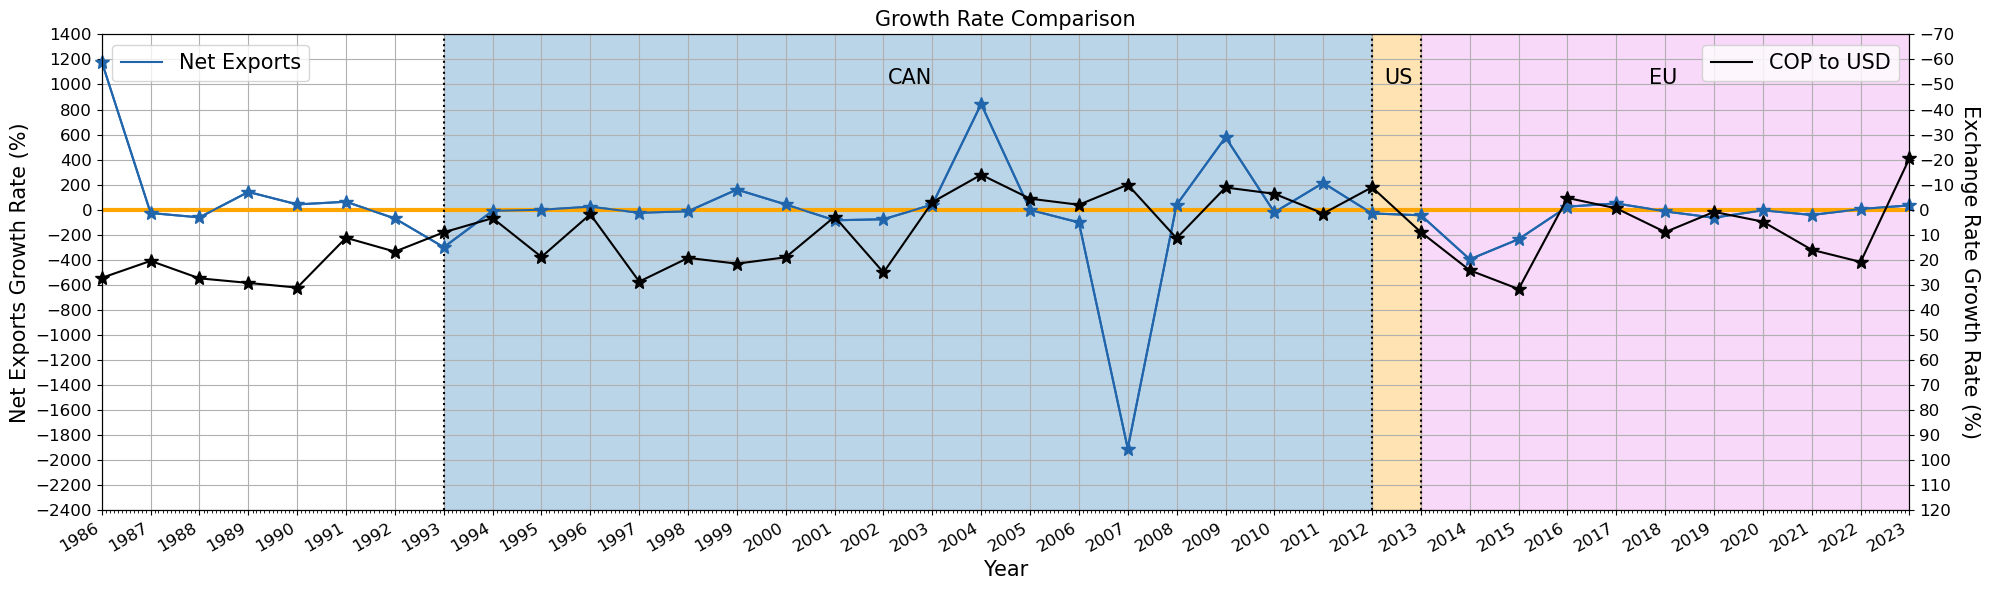

In [10]:
## graph 1, Net Exports and Exchange Rate Growth Rate Graph
fig = plt.figure(figsize=(20,6))
axes = fig.subplots()
## growth rate calculations, had to use absolute difference due to negative growth rate
trm = dolaryear['Tasa de cambio representativa del mercado (TRM)']
trmgrowth = (trm.copy().diff() / trm.copy().abs().shift())*100
trmgrowth.fillna(0,inplace=True)
bal = netports['Balance (in Trillions 0f 2015 COP)']
balgrowth = (bal.copy().diff() / bal.copy().abs().shift())*100
balgrowth.fillna(0,inplace=True)
## dates
dates = netports['Años']
dates = pd.to_datetime(dates, format='%Y')
dates2 = dolaryear['Fecha (dd/mm/aaaa)']
dates2 = pd.to_datetime(dates2, format='%Y')
datesmin = dates2.min()
datesmax = dates2.max()
## title and labels
plt.title('Growth Rate Comparison',fontsize=15)
axes.set_ylabel('Net Exports Growth Rate (%)',fontsize=15)
axes.set_xlabel('Year',fontsize=15)
## lines for each measure
axes.plot(dates,balgrowth,color='#2166ac',label='Net Exports')
axes.plot(dates[2:],balgrowth[2:],color='#2166ac',marker='*',markersize=10, clip_on=False,zorder=3)
## twinx since the growth of each line is very different
axes2=axes.twinx()
axes2.plot(dates2[3:],trmgrowth[3:],'k*',markersize=10, clip_on=False,zorder=3)
axes2.plot(dates2,trmgrowth,color='k',label='COP to USD')
## Set the major ticks to be at the beginning of each year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
## setting Months as minor ticks
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
## disable labels in minor ticks
for label in plt.gca().xaxis.get_minorticklabels():
    label.set_visible(False)
## Improve the plot display
plt.gcf().autofmt_xdate()
## limits and grid
axes.set_ylim(top=1400,bottom=-2400)
axes2.set_ylim(top=120,bottom=-70)
axes.set_xlim(left=dt.date(1986,1,1),right=dt.date(2023, 1, 1))
## grid
axes.grid()
## ticks fix to align the 0 gridline in both sides
nticks = 20
axes.yaxis.set_major_locator(matplotlib.ticker.LinearLocator(nticks))
axes2.yaxis.set_major_locator(matplotlib.ticker.LinearLocator(nticks))
axes.tick_params(axis='both', which='major', labelsize=12)
axes2.tick_params(axis='y', which='major', labelsize=12)
## label for axes2
axes2.set_ylabel('Exchange Rate Growth Rate (%)',fontsize=15,rotation=270,va='bottom')
axes2.invert_yaxis()
## horizontal line at y=0
axes.axhline(y=0,linewidth=3,zorder=2,color='#FFA500')
## Lines and Text for FTAs, Each color is a different ammount of FTAs, blue=1 (CAN), orange=2 (CAN, US), pink=3 (CAN, US, EU)
axes.axvline(x=dt.date(1993, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2012, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2013, 1, 1),linestyle='dotted',color='k')
axes.text(dt.date(2002, 2, 1), 1000, 'CAN',fontsize=15)
axes.text(dt.date(2012, 4, 1), 1000, 'US',fontsize=15)
axes.text(dt.date(2017, 9, 1), 1000, 'EU',fontsize=15)
## Boxes for amounts of FTAs active at the same time
xy = dt.datetime(1993,1,1), axes.get_ylim()[0]
w, h = dt.timedelta(days=6940), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy, w, h,alpha=0.3))
xy2 = dt.datetime(2012,1,1), axes.get_ylim()[0]
w2, h2 = dt.timedelta(days=365), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy2, w2, h2,alpha=0.3,color='orange'))
xy3 = dt.datetime(2013,1,1), axes.get_ylim()[0]
w3, h3 = dt.timedelta(days=3653), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy3, w3, h3,alpha=0.3,color='violet'))
## legend and setting it to upper left and upper right
axes.legend(loc=2,fontsize=15)
axes2.legend(loc=1,fontsize=15)
plt.tight_layout()
plt.savefig('exportsexchange.png')
plt.show()

In [11]:
## Prices for Brent Crude Oil in dollars per barrel
oil2 = pd.read_excel(r"C:\Users\Lenovo\Earth Project\CMO-Historical-Data-Annual.xlsx",skiprows=7,usecols='A,C',sheet_name='Annual Prices (Nominal)')
oil2.rename(columns={oil2.columns[0]:'Years',oil2.columns[1]:'Brent Crude Oil ($/bbl)'},inplace=True)
oil = oil2.loc[oil2['Years']>=1984].copy().reset_index(drop=True)

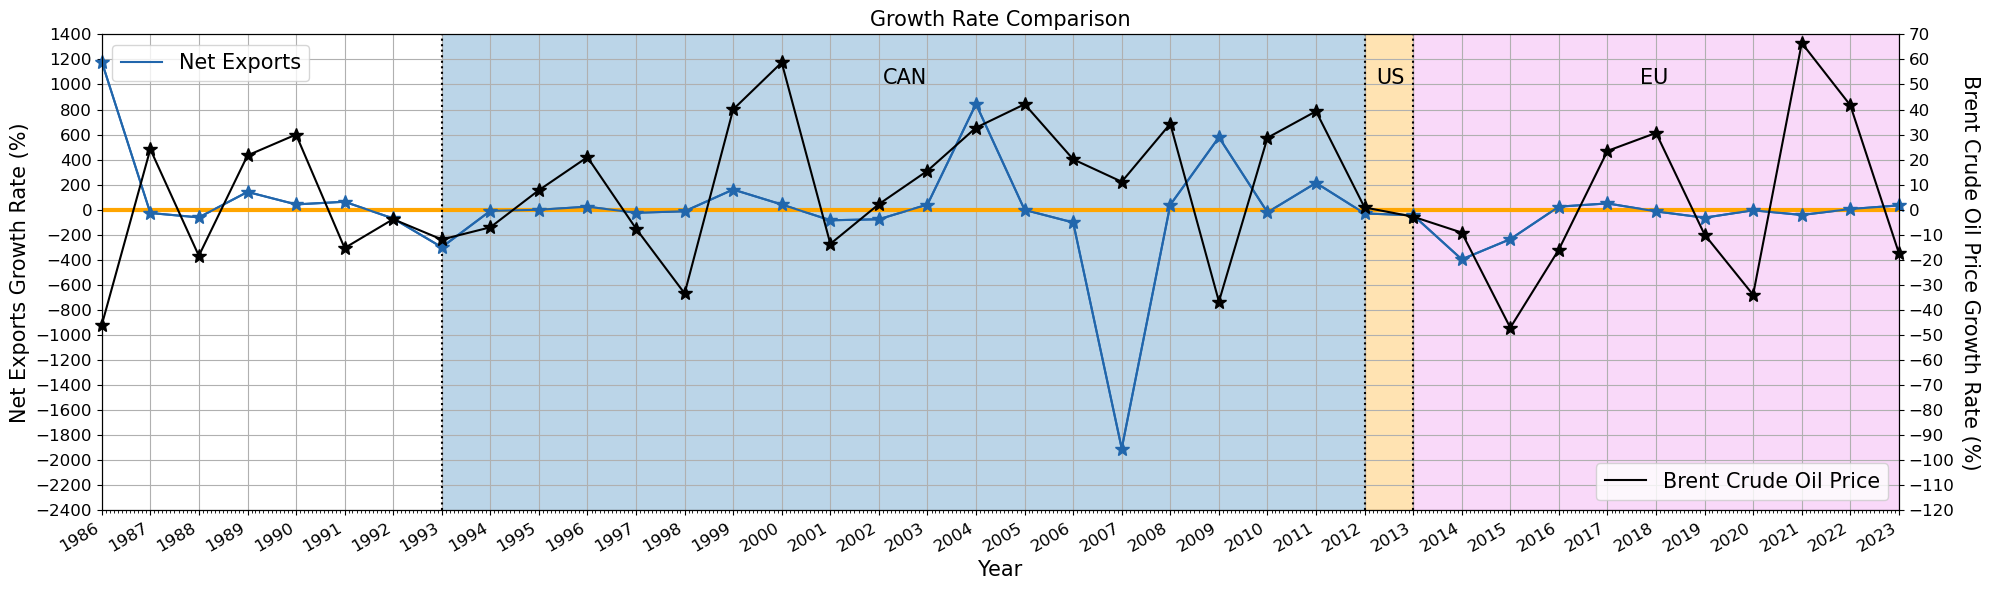

In [12]:
## graph 2, Net Exports and Oil Price Growth Rate Graph
fig = plt.figure(figsize=(20,6))
axes = fig.subplots()
## growth rate calculations, had to use absolute difference due to negative growth rate
brent = oil['Brent Crude Oil ($/bbl)']
brentgrowth = (brent.copy().diff() / brent.copy().abs().shift())*100
brentgrowth.fillna(0,inplace=True)
bal = netports['Balance (in Trillions 0f 2015 COP)']
balgrowth = (bal.copy().diff() / bal.copy().abs().shift())*100
balgrowth.fillna(0,inplace=True)
## dates
dates = netports['Años']
dates = pd.to_datetime(dates, format='%Y')
dates2 = oil['Years']
dates2 = pd.to_datetime(dates2, format='%Y')
datesmin = dates2.min()
datesmax = dates2.max()
## title and labels
plt.title('Growth Rate Comparison',fontsize=15)
axes.set_ylabel('Net Exports Growth Rate (%)',fontsize=15)
axes.set_xlabel('Year',fontsize=15)
## lines for each measure
axes.plot(dates,balgrowth,color='#2166ac',label='Net Exports')
axes.plot(dates[2:],balgrowth[2:],color='#2166ac',marker='*',markersize=10, clip_on=False,zorder=3)
## twinx since the growth of each line is very different
axes2=axes.twinx()
axes2.plot(dates2[2:],brentgrowth[2:],'k*',markersize=10, clip_on=False,zorder=3)
axes2.plot(dates2,brentgrowth,color='k',label='Brent Crude Oil Price')
## Set the major ticks to be at the beginning of each year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
## setting Months as minor ticks
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
## disable labels in minor ticks
for label in plt.gca().xaxis.get_minorticklabels():
    label.set_visible(False)
## Improve the plot display
plt.gcf().autofmt_xdate()
## limits and grid
axes.set_ylim(top=1400,bottom=-2400)
axes2.set_ylim(top=70,bottom=-120)
axes.set_xlim(left=dt.date(1986,1,1),right=dt.date(2023, 1, 1))
## grid
axes.grid()
## ticks fix
nticks = 20
axes.yaxis.set_major_locator(matplotlib.ticker.LinearLocator(nticks))
axes2.yaxis.set_major_locator(matplotlib.ticker.LinearLocator(nticks))
axes.tick_params(axis='both', which='major', labelsize=12)
axes2.tick_params(axis='y', which='major', labelsize=12)
## label for axes2
axes2.set_ylabel('Brent Crude Oil Price Growth Rate (%)',fontsize=15,rotation=270,va='bottom')
## horizontal line at y=0
axes.axhline(y=0,linewidth=3,zorder=2,color='#FFA500')
## Lines and Text for FTAs, Each color is a different ammount of FTAs, blue=1 (CAN), orange=2 (CAN, US), pink=3 (CAN, US, EU)
axes.axvline(x=dt.date(1993, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2012, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2013, 1, 1),linestyle='dotted',color='k')
axes.text(dt.date(2002, 2, 1), 1000, 'CAN',fontsize=15)
axes.text(dt.date(2012, 4, 1), 1000, 'US',fontsize=15)
axes.text(dt.date(2017, 9, 1), 1000, 'EU',fontsize=15)
## Boxes for amounts of FTAs active at the same time
xy = dt.datetime(1993,1,1), axes.get_ylim()[0]
w, h = dt.timedelta(days=6940), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy, w, h,alpha=0.3))
xy2 = dt.datetime(2012,1,1), axes.get_ylim()[0]
w2, h2 = dt.timedelta(days=365), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy2, w2, h2,alpha=0.3,color='orange'))
xy3 = dt.datetime(2013,1,1), axes.get_ylim()[0]
w3, h3 = dt.timedelta(days=3653), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy3, w3, h3,alpha=0.3,color='violet'))
## legend and setting it to upper left and upper right
axes.legend(loc=2,fontsize=15)
axes2.legend(loc=4,fontsize=15)
plt.tight_layout()
plt.savefig('exportsbrent.png')
plt.show()

In [13]:
## Data for exports to top 3 destinations from 1991, Central Bank Data was not complete
cexp = pd.read_excel(r"C:\Users\Lenovo\Earth Project\Expo  ZONA PAIS.xlsx", skiprows=5,usecols='A:AH')
cexp2 = pd.DataFrame(cexp.iloc[3]).reset_index()
cexp3 = pd.DataFrame(cexp.iloc[16]).reset_index()
cexp4 = pd.DataFrame(cexp.iloc[26]).reset_index()
## Separating and fixing for the top 3
cexp2 = cexp2.rename(columns={'index':'Año',3:'CAN'})
cexp22 = cexp2.iloc[1:].copy()
cexp22['CAN'] = cexp22['CAN'].str.replace(',', '.').apply(lambda x: float(x))
cexp3 = cexp3.rename(columns={'index':'Año',16:'United States'})
cexp33 = cexp3.iloc[1:].copy()
cexp33['United States'] = cexp33['United States'].str.replace(',', '.').apply(lambda x: float(x))
cexp4 = cexp4.rename(columns={'index':'Año',26:'European Union'})
cexp44 = cexp4.iloc[1:].copy()
cexp44['European Union'] = cexp44['European Union'].str.replace(',', '.').apply(lambda x: float(x))
## Correcting units
cexptop3 = cexp22.copy()
cexptop3['United States'] = cexp33['United States'].copy()
cexptop3['European Union'] = cexp44['European Union'].copy()
cexptop3 = cexptop3.reset_index(drop=True)
cexptop3['Año'] = cexptop3['Año'].apply(lambda x: int(x))

In [14]:
## Export information from IMF, only for the EU and US
cexp5 = pd.read_excel(r"C:\Users\Lenovo\Earth Project\Exports_and_Imports_by_Areas_and_Co.xlsx",skiprows=6,usecols='B:I')
cexp55 = cexp5.loc[cexp5['Country']=='United States'].copy()
cexp56 = cexp5.loc[cexp5['Country']=='European Union'].copy()
## Export information from CAN, only for themselves
cexp6 = pd.read_excel(r"C:\Users\Lenovo\Earth Project\Serie_Comercio_Exterior.xlsx",usecols='A,D',skiprows=10,skipfooter=1,sheet_name='11')
cexp66 = cexp6.loc[(cexp6['Año']>=1984)].copy()
cexp66 = cexp66.loc[cexp66['Año']<=1990].reset_index(drop=True)
## Unit fixing
cexp66['Año'] = cexp66['Año'].astype(int)
cexp66['Año']= pd.to_datetime(cexp66['Año'],format='%Y')
cexp66['Año']=cexp66['Año'].dt.strftime('%Y')
cexp666 = cexp66.T.reset_index().copy()
cexp666.columns = cexp666.iloc[0].copy()
cexp667 = cexp666.iloc[1:].copy()
cexp667 = cexp667.reset_index(drop=True)
cexp667.rename(columns={'Año':'Country'},inplace=True)
trabajo3 = cexp667.iloc[0].values[1:].copy()
## Units are different, fixing that
cexp668 = pd.DataFrame(trabajo3/1000)
cexp668 = cexp668.T
cexp668.insert(0, "Año",'CAN')
cexp668.columns=cexp667.columns.copy()
## Uniting the Data from the 2 databases
cexptop33 = pd.concat([cexp668,cexp55,cexp56])
cexptop33 = cexptop33.reset_index(drop=True)
cexptop34 = cexptop33.copy()
## Fixing format since units are different
n=0
for i in cexptop34:
    while n<=2:
        cexptop34.iloc[n].values[1:] = cexptop33.iloc[n].values[1:]*1e6
        n+=1
    break
cexptop35 = cexptop34.copy()
n = 1984
for i in cexptop35:
    while n<=1990:
        cexptop35[f'{n}'] = cexptop35[f'{n}'].apply(lambda x: float(x))
        n+=1
    break
## Fixing the dataframe
cexptop36 = cexptop35.T.reset_index()
cexptop36.columns = cexptop36.iloc[0]
cexptop36.rename(columns={'Country':'Año'},inplace=True)
cexptop36 = cexptop36.iloc[1:]
cexptop36['CAN'] = cexptop36['CAN'].apply(lambda x: float(x))
cexptop36['United States'] = cexptop36['United States'].apply(lambda x: float(x))
cexptop36['European Union'] = cexptop36['European Union'].apply(lambda x: float(x))
## Uniting Central Bank df and the already fixed IMF-CAN data
cexptop333 = pd.concat([cexptop36,cexptop3]).reset_index(drop=True)

In [15]:
## deflated numbers for each trade partner
canexports = ((((cexptop333['CAN']*dolarflatoravg2['TRM'])/deflator['Deflator'])*100).astype(float))/1e12
usexports = ((((cexptop333['United States']*dolarflatoravg2['TRM'])/deflator['Deflator'])*100).astype(float))/1e12
euexports = ((((cexptop333['European Union']*dolarflatoravg2['TRM'])/deflator['Deflator'])*100).astype(float))/1e12

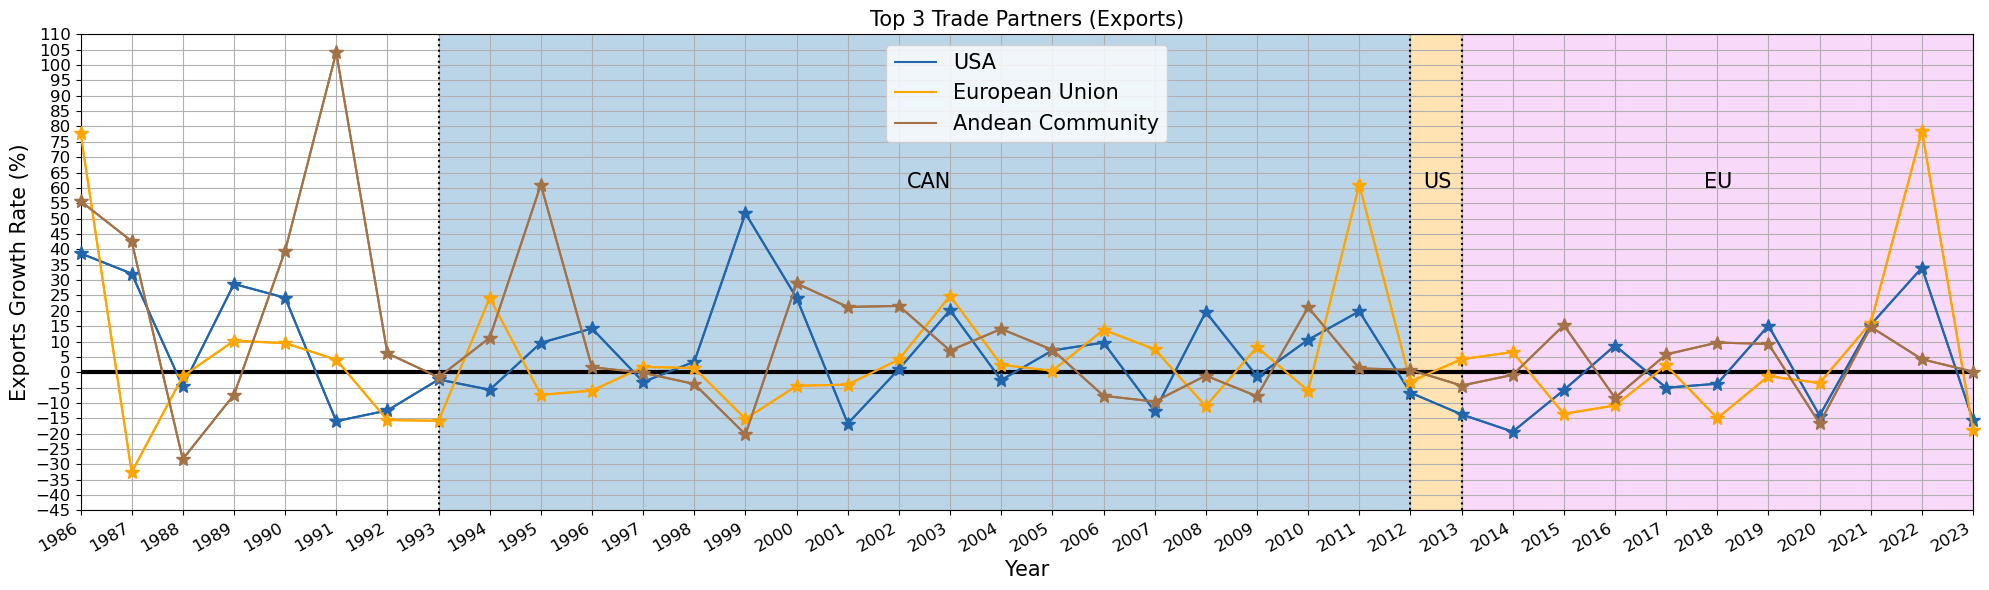

In [16]:
## graph 3, Growth Rate of Exports toward top 3 trade partners
fig = plt.figure(figsize=(20,6))
axes = fig.subplots()
gringos = usexports
gringosrate = (gringos.copy().diff() / gringos.copy().abs().shift())*100
gringosrate.fillna(0,inplace=True)
europeos = euexports
europeosrate = (europeos.copy().diff() / europeos.copy().abs().shift())*100
europeosrate.fillna(0,inplace=True)
suramericanos = canexports
suramericanosrate = (suramericanos.copy().diff() / suramericanos.copy().abs().shift())*100
suramericanosrate.fillna(0,inplace=True)
dates1 = cexptop333['Año']
dates1 = pd.to_datetime(dates1, format='%Y')
datesmin1 = dates1.min()
datesmax1 = dates1.max()
## title and labels
plt.title('Top 3 Trade Partners (Exports)',fontsize=15)
axes.set_ylabel('Exports Growth Rate (%)',fontsize=15)
axes.set_xlabel('Year',fontsize=15)
## lines for each measure
axes.plot(dates1,gringosrate,color='#2166ac',label='USA')
axes.plot(dates1[2:],gringosrate[2:],color='#2166ac',marker='*',markersize=10, clip_on=False,zorder=3)

axes.plot(dates1,europeosrate,color='#FFA500',label='European Union')
axes.plot(dates1[2:],europeosrate[2:],color='#FFA500',marker='*',markersize=10, clip_on=False,zorder=3)

axes.plot(dates1,suramericanosrate,color='#A47247',label='Andean Community')
axes.plot(dates1[2:],suramericanosrate[2:],color='#A47247',marker='*',markersize=10, clip_on=False,zorder=3)
# Set the major ticks to be at the beginning of each year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Improve the plot display
plt.gcf().autofmt_xdate()
## limits and grid
axes.set_xlim(left=dt.date(1986, 1, 1),right=datesmax1)
axes.set_ylim(top=110,bottom=-45)
## grid
axes.grid()
## ticks fix
axes.tick_params(axis='both', which='major', labelsize=12)
nticks = 32
axes.yaxis.set_major_locator(matplotlib.ticker.LinearLocator(nticks))
## horizontal line
axes.axhline(y=0,linewidth=3,zorder=2,color='#000000')
## Lines and Text for FTAs
axes.axvline(x=dt.date(1993, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2012, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2013, 1, 1),linestyle='dotted',color='k')
axes.text(dt.date(2002, 3, 1), 60, 'CAN',fontsize=15)
axes.text(dt.date(2012, 4, 1), 60, 'US',fontsize=15)
axes.text(dt.date(2017, 10, 1), 60, 'EU',fontsize=15)
## Boxes for amounts of FTAs active at the same time
xy = dt.datetime(1993,1,1), axes.get_ylim()[0]
w, h = dt.timedelta(days=6940), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy, w, h,alpha=0.3))
xy2 = dt.datetime(2012,1,1), axes.get_ylim()[0]
w2, h2 = dt.timedelta(days=365), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy2, w2, h2,alpha=0.3,color='orange'))
xy3 = dt.datetime(2013,1,1), axes.get_ylim()[0]
w3, h3 = dt.timedelta(days=3653), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy3, w3, h3,alpha=0.3,color='violet'))
## legend and setting it to upper left and upper right
axes.legend(loc="best",fontsize=15)
plt.tight_layout()
plt.savefig('top3exports.png')
plt.show()

In [17]:
## Import information comes from the same source as export info, so, same process
cimp = pd.read_excel(r"C:\Users\Lenovo\Earth Project\Importaciones Zonas de Países cifdo.xlsx", skiprows=5,usecols='A:AH')
cimp2 = pd.DataFrame(cimp.iloc[3]).reset_index()
cimp3 = pd.DataFrame(cimp.iloc[18]).reset_index()
cimp4 = pd.DataFrame(cimp.iloc[30]).reset_index()

cimp2 = cimp2.rename(columns={'index':'Año',3:'CAN'})
cimp22 = cimp2.iloc[1:].copy()
cimp22['CAN'] = cimp22['CAN'].str.replace(',', '.').apply(lambda x: float(x))
cimp3 = cimp3.rename(columns={'index':'Año',18:'United States'})
cimp33 = cimp3.iloc[1:].copy()
cimp33['United States'] = cimp33['United States'].str.replace(',', '.').apply(lambda x: float(x))
cimp4 = cimp4.rename(columns={'index':'Año',30:'European Union'})
cimp44 = cimp4.iloc[1:].copy()
cimp44['European Union'] = cimp44['European Union'].str.replace(',', '.').apply(lambda x: float(x))

cimptop3 = cimp22.copy()
cimptop3['United States'] = cimp33['United States'].copy()
cimptop3['European Union'] = cimp44['European Union'].copy()
cimptop3 = cimptop3.reset_index(drop=True)
cimptop3['Año'] = cimptop3['Año'].apply(lambda x: int(x))

In [18]:
## Same process as export info
cimp5 = pd.read_excel(r"C:\Users\Lenovo\Earth Project\Exports_and_Imports_by_Areas_and_Co.xlsx",skiprows=6,usecols='B:I',sheet_name='Imports, CIF')
cimp55 = cimp5.loc[cimp5['Country']=='United States'].copy()
cimp56 = cimp5.loc[cimp5['Country']=='European Union'].copy()
cimp6 = pd.read_excel(r"C:\Users\Lenovo\Earth Project\Serie_Comercio_Exterior.xlsx",usecols='A,D',skiprows=10,skipfooter=1,sheet_name='12')
cimp66 = cimp6.loc[(cimp6['Año']>=1984)].copy()
cimp66 = cimp66.loc[cimp66['Año']<=1990].reset_index(drop=True)
cimp66['Año'] = cimp66['Año'].astype(int)
cimp66['Año']= pd.to_datetime(cimp66['Año'],format='%Y')
cimp66['Año']=cimp66['Año'].dt.strftime('%Y')
cimp666 = cimp66.T.reset_index().copy()
cimp666.columns = cimp666.iloc[0].copy()
cimp667 = cimp666.iloc[1:].copy()
cimp667 = cimp667.reset_index(drop=True)
cimp667.rename(columns={'Año':'Country'},inplace=True)
trabajo3 = cimp667.iloc[0].values[1:].copy()
cimp668 = pd.DataFrame(trabajo3/1000)
cimp668 = cimp668.T
cimp668.insert(0, "Año",'CAN')
cimp668.columns=cimp667.columns.copy()

cimptop33 = pd.concat([cimp668,cimp55,cimp56])
cimptop33 = cimptop33.reset_index(drop=True)
cimptop34 = cimptop33.copy()
n=0
for i in cimptop34:
    while n<=2:
        cimptop34.iloc[n].values[1:] = cimptop33.iloc[n].values[1:]*1e6
        n+=1
    break
cimptop35 = cimptop34.copy()
n = 1985
for i in cimptop35:
    while n<=1990:
        cimptop35[f'{n}'] = cimptop35[f'{n}'].apply(lambda x: float(x))
        n+=1
    break
cimptop36 = cimptop35.T.reset_index()
cimptop36.columns = cimptop36.iloc[0]
cimptop36.rename(columns={'Country':'Año'},inplace=True)
cimptop36 = cimptop36.iloc[1:]
cimptop36['CAN'] = cimptop36['CAN'].apply(lambda x: float(x))
cimptop36['United States'] = cimptop36['United States'].apply(lambda x: float(x))
cimptop36['European Union'] = cimptop36['European Union'].apply(lambda x: float(x))

cimptop333 = pd.concat([cimptop36,cimptop3]).reset_index(drop=True)

In [19]:
## deflated numbers for each trade partner
canimports = ((((cimptop333['CAN']*dolarflatoravg2['TRM'])/deflator['Deflator'])*100).astype(float))/1e12
usimports = ((((cimptop333['United States']*dolarflatoravg2['TRM'])/deflator['Deflator'])*100).astype(float))/1e12
euimports = ((((cimptop333['European Union']*dolarflatoravg2['TRM'])/deflator['Deflator'])*100).astype(float))/1e12

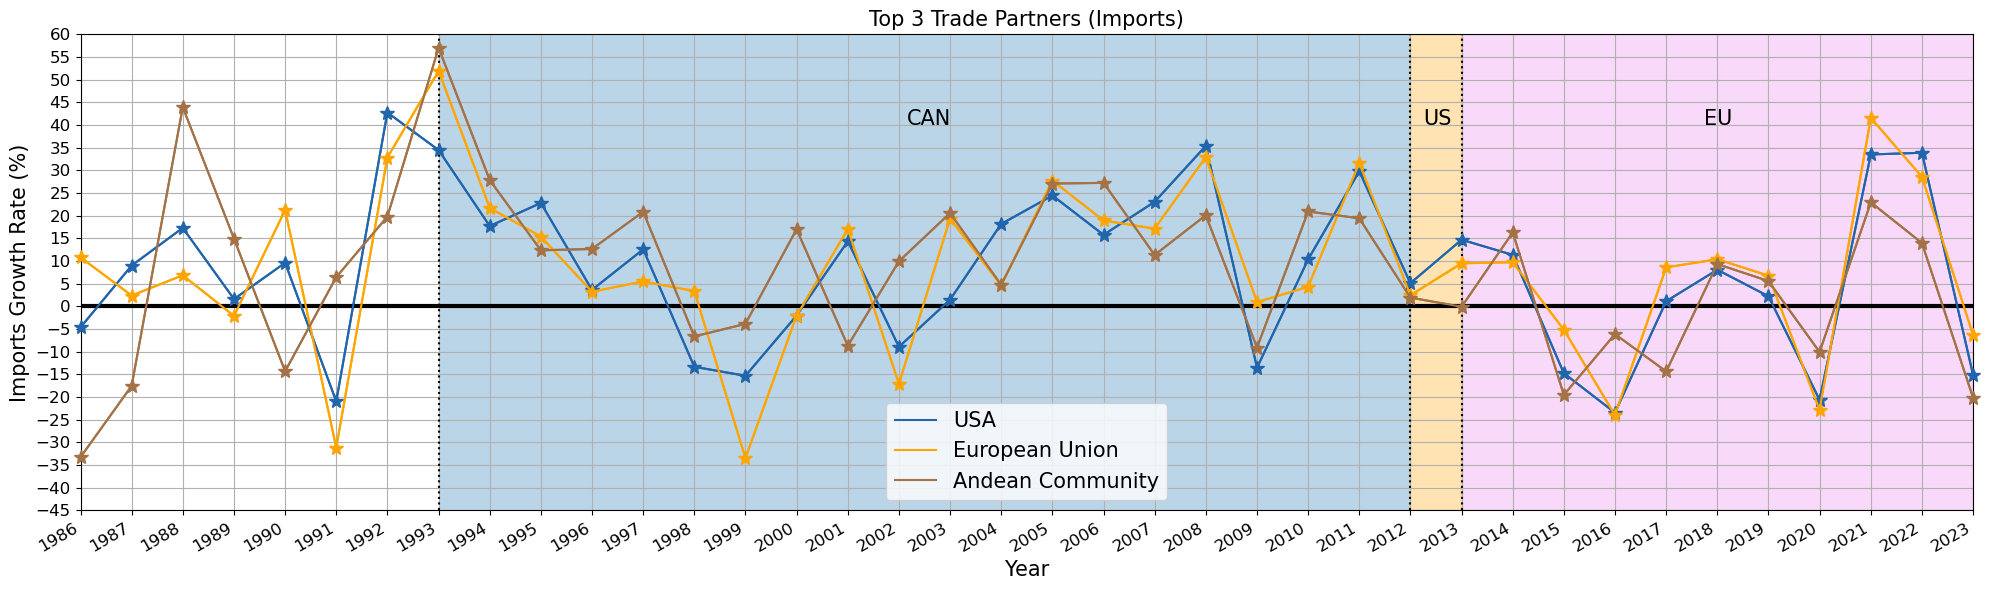

In [20]:
## graph 4, Growth Rate of Imports from top 3 trade partners
fig = plt.figure(figsize=(20,6))
axes = fig.subplots()
gringos2 = cimptop333['United States']
gringos2rate = (gringos2.copy().diff() / gringos2.copy().abs().shift())*100
gringos2rate.fillna(0,inplace=True)
europeos2 = cimptop333['European Union']
europeos2rate = (europeos2.copy().diff() / europeos2.copy().abs().shift())*100
europeos2rate.fillna(0,inplace=True)
suramericanos2 = cimptop333['CAN']
suramericanos2rate = (suramericanos2.copy().diff() / suramericanos2.copy().abs().shift())*100
suramericanos2rate.fillna(0,inplace=True)
dates11 = cimptop333['Año']
dates11 = pd.to_datetime(dates11, format='%Y')
datesmin11 = dates11.min()
datesmax11 = dates11.max()
## title and labels
plt.title('Top 3 Trade Partners (Imports)',fontsize=15)
axes.set_ylabel('Imports Growth Rate (%)',fontsize=15)
axes.set_xlabel('Year',fontsize=15)
## lines for each measure
axes.plot(dates11,gringos2rate,color='#2166ac',label='USA')
axes.plot(dates11[2:],gringos2rate[2:],color='#2166ac',marker='*',markersize=10, clip_on=False,zorder=3)

axes.plot(dates11,europeos2rate,color='#FFA500',label='European Union')
axes.plot(dates11[2:],europeos2rate[2:],color='#FFA500',marker='*',markersize=10, clip_on=False,zorder=3)

axes.plot(dates11,suramericanos2rate,color='#A47247',label='Andean Community')
axes.plot(dates11[2:],suramericanos2rate[2:],color='#A47247',marker='*',markersize=10, clip_on=False,zorder=3)
# Set the major ticks to be at the beginning of each year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Improve the plot display
plt.gcf().autofmt_xdate()
## limits and grid
axes.set_xlim(left=dt.date(1986, 1, 1),right=datesmax11)
axes.set_ylim(top=60,bottom=-45)
## grid
axes.grid()
## ticks fix
axes.tick_params(axis='both', which='major', labelsize=12)
nticks = 22
axes.yaxis.set_major_locator(matplotlib.ticker.LinearLocator(nticks))
## horizontal line
axes.axhline(y=0,linewidth=3,zorder=2,color='#000000')
## Lines and Text for FTAs
axes.axvline(x=dt.date(1993, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2012, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2013, 1, 1),linestyle='dotted',color='k')
axes.text(dt.date(2002, 3, 1), 40, 'CAN',fontsize=15)
axes.text(dt.date(2012, 4, 1), 40, 'US',fontsize=15)
axes.text(dt.date(2017, 10, 1), 40, 'EU',fontsize=15)
## Boxes for amounts of FTAs active at the same time
xy = dt.datetime(1993,1,1), axes.get_ylim()[0]
w, h = dt.timedelta(days=6940), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy, w, h,alpha=0.3))
xy2 = dt.datetime(2012,1,1), axes.get_ylim()[0]
w2, h2 = dt.timedelta(days=365), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy2, w2, h2,alpha=0.3,color='orange'))
xy3 = dt.datetime(2013,1,1), axes.get_ylim()[0]
w3, h3 = dt.timedelta(days=3653), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy3, w3, h3,alpha=0.3,color='violet'))
## legend and setting it to best loc
axes.legend(loc='best',fontsize=15)
plt.tight_layout()
plt.savefig('top3imports.png')
plt.show()

In [41]:
## Impprting inflation data from World Bank
cpiworld = pd.read_excel(r"C:\Users\Lenovo\Earth Project\API_FP.CPI.TOTL_DS2_en_excel_v2_329.xls",skiprows=3,skipfooter=100)
cpi2 = cpiworld.iloc[45]
cpi2 = pd.DataFrame(cpi2).T.reset_index(drop=True)
cpi2 = cpi2.drop(columns=cpi2.columns[1:28])
cpi2['1986'] = cpi2['1986'].apply(lambda x: float(x))
cpi2['2022'] = cpi2['2022'].apply(lambda x: float(x))
cpi2 = cpi2.T.reset_index()
cpi2.columns = cpi2.loc[0]
cpi = cpi2.iloc[1:].reset_index(drop=True)
## adding number obtained from IMF dataset to the not updated WB dataset
cpi['Colombia'].iloc[39] = 184.119324369034
cpi.rename(columns={'Country Name':'Año'},inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20852\760615976.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  cpi['Colombia'].iloc[39] = 184.119324369034


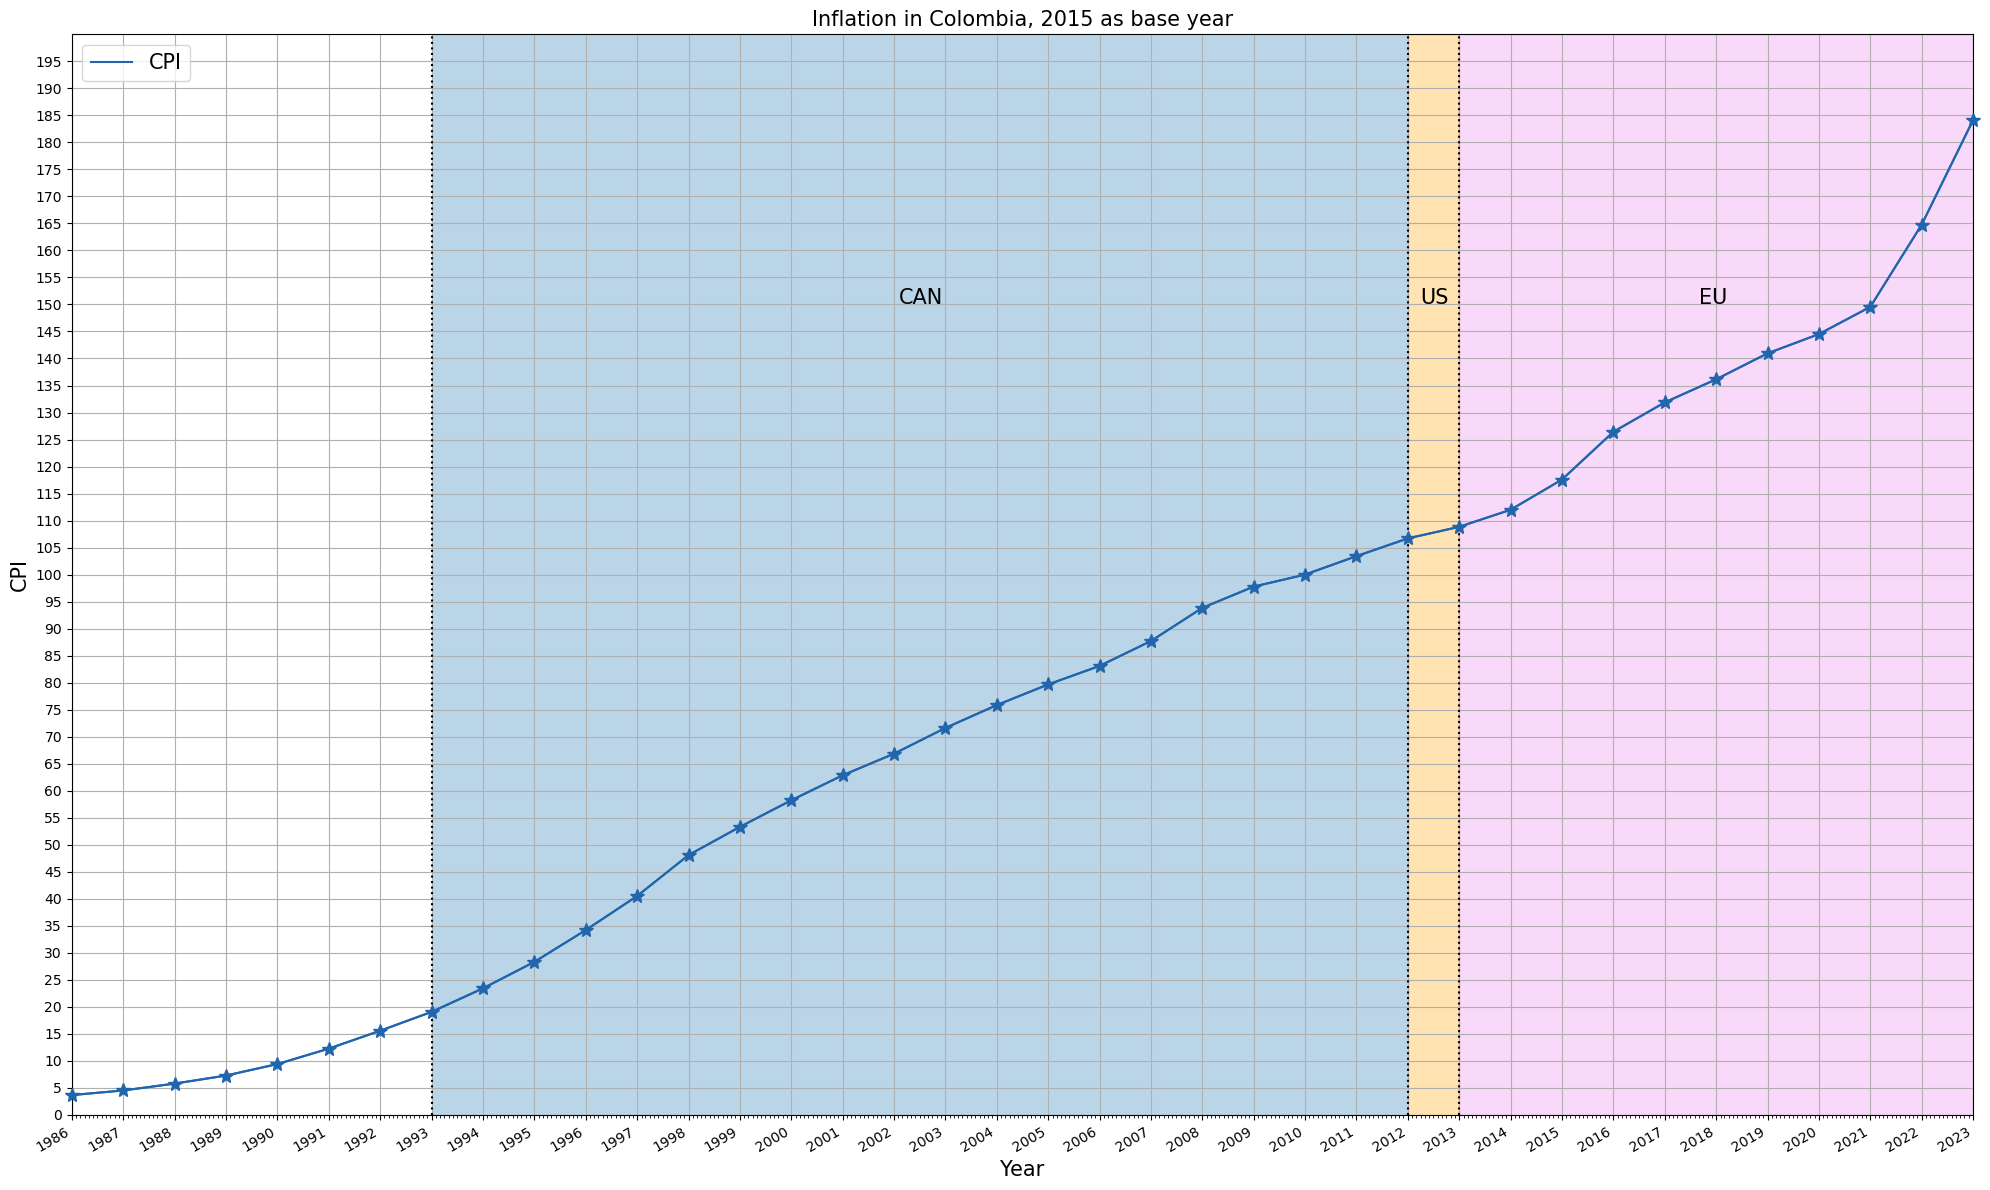

In [43]:
## graph 5, Inflation (historical)
fig = plt.figure(figsize=(20,12))
axes = fig.subplots()
## dates
cpirate = cpi['Colombia']
dates = cpi['Año']
dates = pd.to_datetime(dates, format='%Y')
datesmin = dates.min()
datesmax = dates.max()
## title and labels
plt.title('Inflation in Colombia, 2015 as base year',fontsize=15)
axes.set_ylabel('CPI',fontsize=15)
axes.set_xlabel('Year',fontsize=15)
## lines for each measure
axes.plot(dates,cpirate,color='#2166ac',label='CPI')
axes.plot(dates[2:],cpirate[2:],color='#2166ac',marker='*',markersize=10, clip_on=False,zorder=3)
# Set the major ticks to be at the beginning of each year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
## setting Months as minor ticks
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
# (Optional) You can disable the minor tick labels if you just want the ticks without labels
for label in plt.gca().xaxis.get_minorticklabels():
    label.set_visible(False)
# Improve the plot display
plt.gcf().autofmt_xdate()
## limits and grid
axes.set_ylim(top=200,bottom=0)
axes.set_xlim(left=dt.date(1986,1,1),right=dt.date(2023, 1, 1))
## grid
axes.grid()
## Lines and Text for FTAs
axes.axvline(x=dt.date(1993, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2012, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2013, 1, 1),linestyle='dotted',color='k')
axes.text(dt.date(2002, 2, 1), 150, 'CAN',fontsize=15)
axes.text(dt.date(2012, 4, 1), 150, 'US',fontsize=15)
axes.text(dt.date(2017, 9, 1), 150, 'EU',fontsize=15)
## Boxes for amounts of FTAs active at the same time
xy = dt.datetime(1993,1,1), axes.get_ylim()[0]
w, h = dt.timedelta(days=6940), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy, w, h,alpha=0.3))
xy2 = dt.datetime(2012,1,1), axes.get_ylim()[0]
w2, h2 = dt.timedelta(days=365), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy2, w2, h2,alpha=0.3,color='orange'))
xy3 = dt.datetime(2013,1,1), axes.get_ylim()[0]
w3, h3 = dt.timedelta(days=3653), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy3, w3, h3,alpha=0.3,color='violet'))
# yticks
plt.yticks(np.arange(0, 200, step=5))
## legend and setting it to upper left and upper right
axes.legend(loc=2,fontsize=15)
plt.tight_layout()
plt.savefig('unemployment.png')
plt.show()

In [44]:
## Written from PDF taken from La Republica website
empresas4 = ['Ecopetrol','Esso Colombiana','Codi-Mobil','Avianca','Bavaria','Coltejer','Flota Mercante Grancolombiana','Colmotores','Codenalco','Sofasa','Coltabaco','ISA','Almacenes Exito','Carton de Colombia','Monomeros Colombo Venezolanos','Grupo Carvajal','Fabricato','Acerias Paz del Rio','Compañia de Galletas Noel','Compañia Nacional de Chocolates (Nutresa)']
extranjeras4 = ['Esso Colombiana','Codi-Mobil','Colmotores','Sofasa','Carton de Colombia']
nacionales44 = []
n=0
for i in empresas4:
    if i not in extranjeras4:
        nacionales44+=(i,n)
        n+=1
## Written from PDF taken from La Republica website
ingresos44 = [291.066,77.161,76.627,68.023,43.792,42.039,39.878,35.957,35.242,34.511,33.950,32.343,30.919,28.529,27.393,27.107,26.817,24.924,21.326,21.293]
cuatroingresos = pd.DataFrame(ingresos44)
cuatroingresos = cuatroingresos.rename(columns={0:'Income (in Millions of COP)'})
## top 20 df using the ;osts from above as well as for loop results
top204 = pd.DataFrame(data=zip(empresas4,cuatroingresos['Income (in Millions of COP)']),columns=['Corporations','Income (in Millions of COP)'])
## fixing and separating by Parent Company Origin, adjusting for inflation
nacionales4 = nacionales44[0::2]
nac4 = pd.DataFrame(nacionales4)
nac4 = nac4.rename(columns={0:'Empresas'})
locales4 = top204.merge(nac4,left_on='Corporations',right_on='Empresas',how='inner')
locales4.drop(columns=['Empresas'],inplace=True)
locales4['Income (deflated, 2015=100)'] = (locales4['Income (in Millions of COP)']*1e6/deflator['Deflator'].iloc[2])*100
## fixing and separating by Parent Company Origin, adjusting for inflation
ext4 = pd.DataFrame(extranjeras4)
ext4 = ext4.rename(columns={0:'Empresas'})
foraneas4 = top204.merge(ext4,left_on='Corporations',right_on='Empresas',how='inner')
foraneas4.drop(columns=['Empresas'],inplace=True)
foraneas4['Income (deflated, 2015=100)'] = (foraneas4['Income (in Millions of COP)']*1e6/deflator['Deflator'].iloc[2])*100

In [45]:
## deflated top 20
top204['Income (deflated, 2015=100)'] = (top204['Income (in Millions of COP)']*1e6/deflator['Deflator'].iloc[2])*100

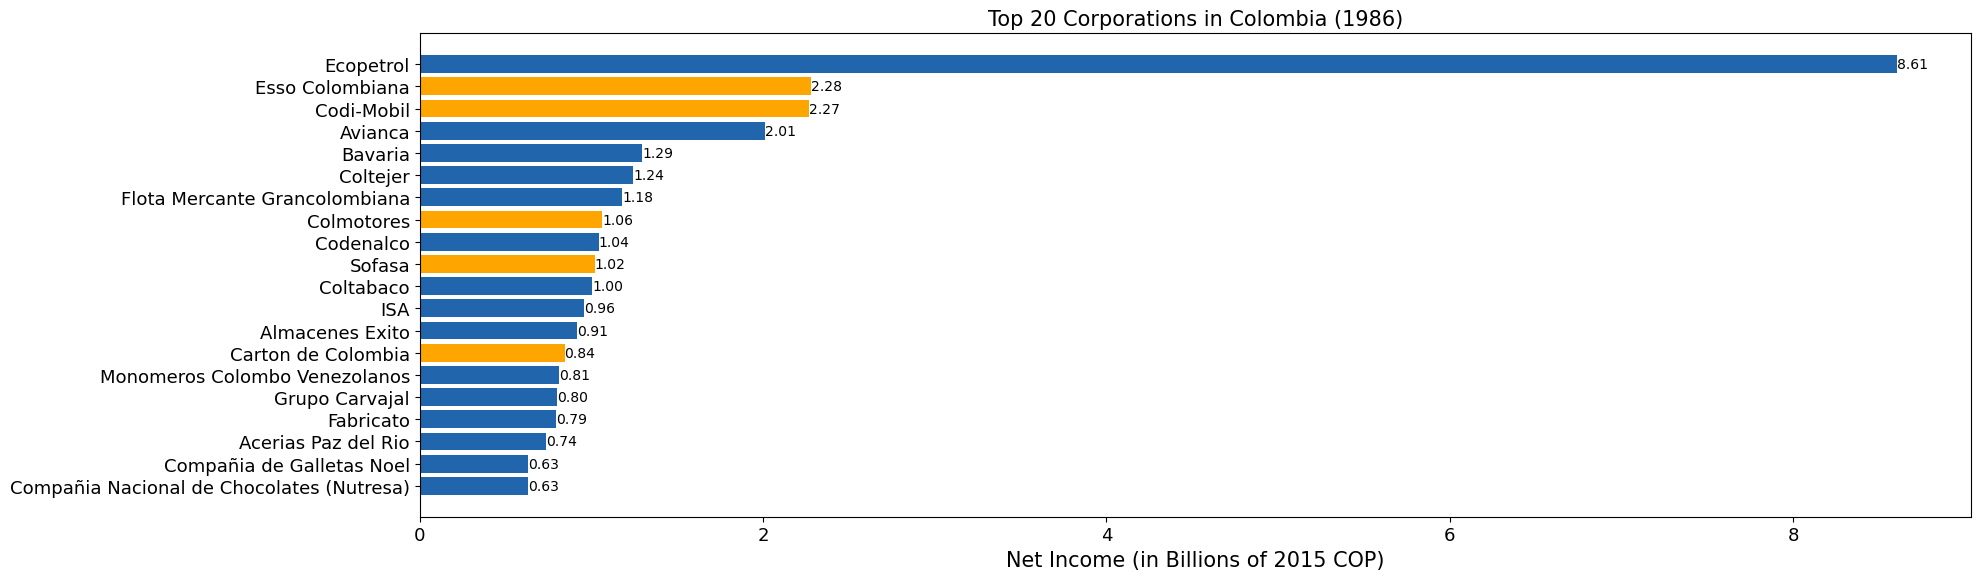

In [46]:
## assigning variable
income1986 = (top204['Income (deflated, 2015=100)'].copy())/1e9
## graph 6, top 20 corporations by income in 1986 
fig = plt.figure(figsize=(20,6))
axes = fig.subplots()
colores = ['#2166ac','#FFA500','#FFA500','#2166ac','#2166ac','#2166ac','#2166ac','#FFA500','#2166ac','#FFA500','#2166ac','#2166ac','#2166ac','#FFA500','#2166ac','#2166ac','#2166ac','#2166ac','#2166ac','#2166ac']
bar = axes.barh(empresas4,income1986,color=colores)
axes.bar_label(bar, fmt='%.2f')
plt.rcParams['font.size'] = 13
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.title('Top 20 Corporations in Colombia (1986)',fontsize=15)
axes.set_xlabel('Net Income (in Billions of 2015 COP)',fontsize=15)
axes.invert_yaxis()
plt.tight_layout()
plt.savefig('top201986.png')
plt.show()

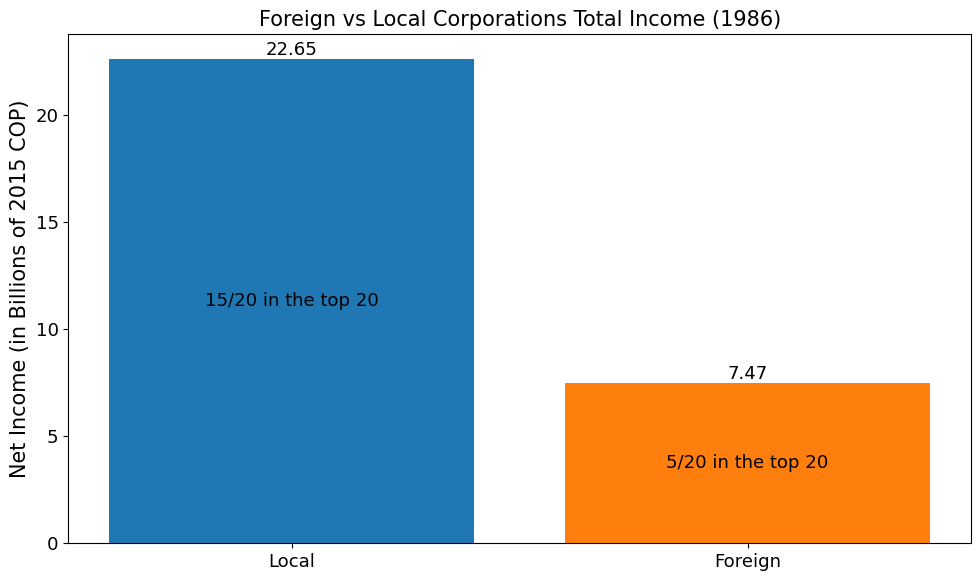

In [47]:
## assigning variable and adjusting
locales1986 = (locales4['Income (deflated, 2015=100)'].copy())/1e9
foraneas1986 = (foraneas4['Income (deflated, 2015=100)'].copy())/1e9
## adding up totals
colombiano4 = locales1986.sum()
eforaneas4 = foraneas1986.sum()
## graph 7, top 20 corporation income totals in 1986, separated by Parent company country of origin
fig = plt.figure(figsize=(10,6))
axes = fig.subplots()
bar = axes.bar('Local',colombiano4)
axes.bar_label(bar, fmt='%.2f')
axes.bar_label(bar, label_type='center',fmt='15/20 in the top 20')
bar2 = axes.bar('Foreign',eforaneas4)
axes.bar_label(bar2, fmt='%.2f')
axes.bar_label(bar2, label_type='center',fmt='5/20 in the top 20')
plt.rcParams['font.size'] = 13
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.title('Foreign vs Local Corporations Total Income (1986)',fontsize=15)
axes.set_ylabel('Net Income (in Billions of 2015 COP)',fontsize=15)
plt.tight_layout()
plt.savefig('top201986foreignlocal.png')
plt.show()

In [48]:
## Database obtained from Supersociedades
reporte2 = pd.read_excel(r"C:\Users\Lenovo\Earth Project\reporte1000_2022.xlsx",skiprows=3,usecols='C,K')
reporte = reporte2.iloc[0:20].copy()
reporte.rename(columns={'RAZÓN SOCIAL':'Corporations','GANANCIA (PÉRDIDA) 2022':'Revenue (in Billions of COP)'},inplace=True)
## Separating names for local corporations and using for loop for foreign
profitempresas = ['Ecopetrol','Cerrejon Carbones','Cenit','EPM','Emgesa','Grupo Energia Bogota','Cerrejon Zona Norte','Ocensa','Grupo Aval','Parex Resources','Marval','Grupo Gilinski','Canacol Energy','Refineria de Cartagena','ISA','Drummond','Claro','Bavaria','Frontera Energy','America Movil Colombia']
reporte['Corporations'] = profitempresas
## deflating numbers
reporte['Income (deflated, 2015=100)'] = (reporte['Revenue (in Billions of COP)']*1e9/deflator['Deflator'].iloc[38])*100
income2022 = (reporte['Income (deflated, 2015=100)'].copy())/1e9
nacionales = ['Ecopetrol','Refineria de Cartagena','EPM','Cenit','Grupo Energia Bogota','Ocensa','Grupo Aval','Marval','Grupo Gilinski','ISA']
extranjeras2 = []
n=0
for i in profitempresas:
    if i not in nacionales:
        extranjeras2+=(i,n)
        n+=1
top20 = pd.DataFrame(data=zip(profitempresas,income2022),columns=['Corporations','Income (deflated, 2015=100)'])
extranjeras = extranjeras2[0::2]
## creating national df
nac = pd.DataFrame(nacionales)
nac = nac.rename(columns={0:'Empresas'})
locales = top20.merge(nac,left_on='Corporations',right_on='Empresas',how='inner')
locales.drop(columns=['Empresas'],inplace=True)
## creating foreign df
ext = pd.DataFrame(extranjeras)
ext = ext.rename(columns={0:'Empresas'})
foraneas = top20.merge(ext,left_on='Corporations',right_on='Empresas',how='inner')
foraneas.drop(columns=['Empresas'],inplace=True)

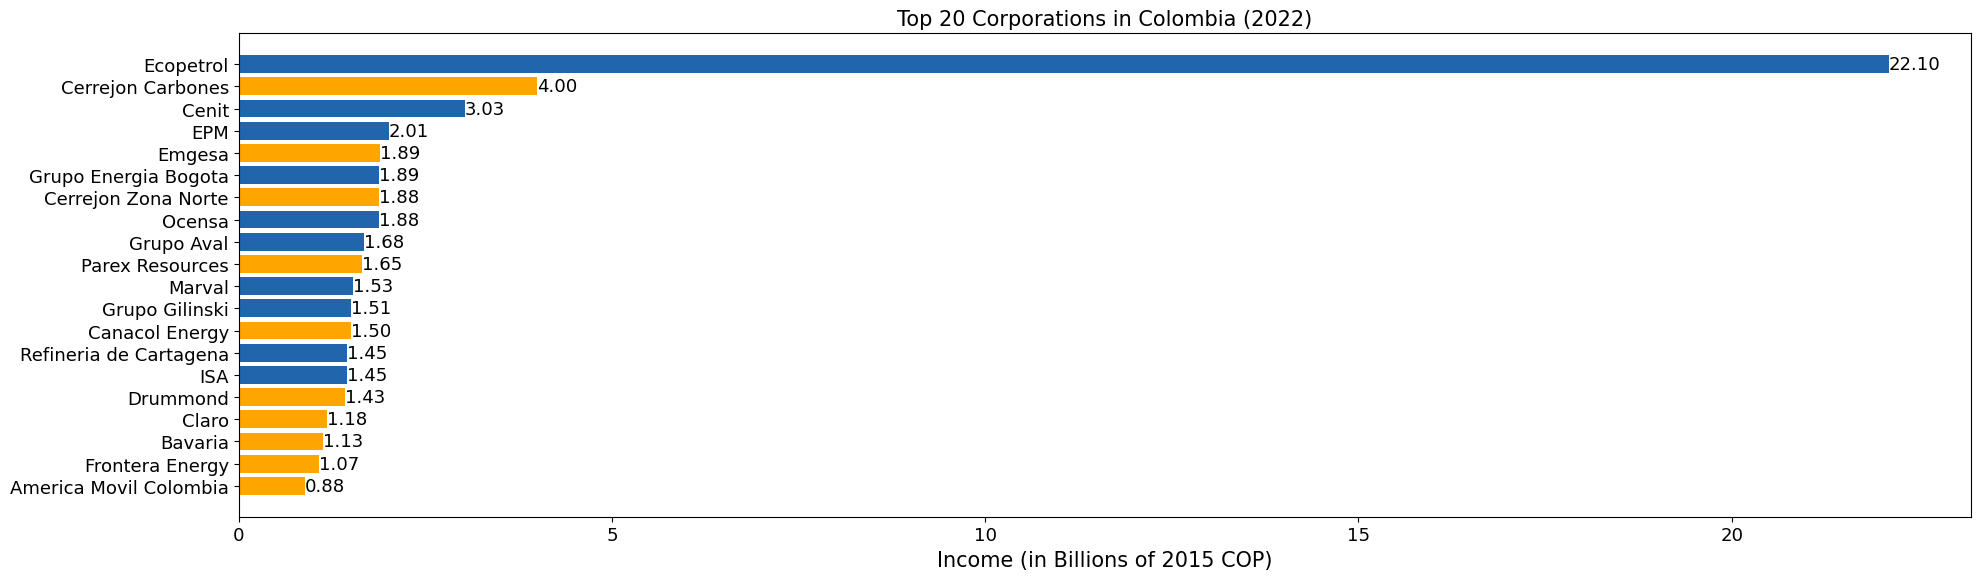

In [49]:
# graph 8, top 20 corporations by income in 2022 
fig = plt.figure(figsize=(20,6))
axes = fig.subplots()
colores = ['#2166ac','#FFA500','#2166ac','#2166ac','#FFA500','#2166ac','#FFA500','#2166ac','#2166ac','#FFA500','#2166ac','#2166ac','#FFA500','#2166ac','#2166ac','#FFA500','#FFA500','#FFA500','#FFA500','#FFA500']
bar = axes.barh(profitempresas,income2022,color=colores)
axes.bar_label(bar, fmt='%.2f')
plt.rcParams['font.size'] = 13
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.title('Top 20 Corporations in Colombia (2022)',fontsize=15)
axes.set_xlabel('Income (in Billions of 2015 COP)',fontsize=15)
axes.invert_yaxis()
plt.tight_layout()
plt.savefig('top202022.png')
plt.show()

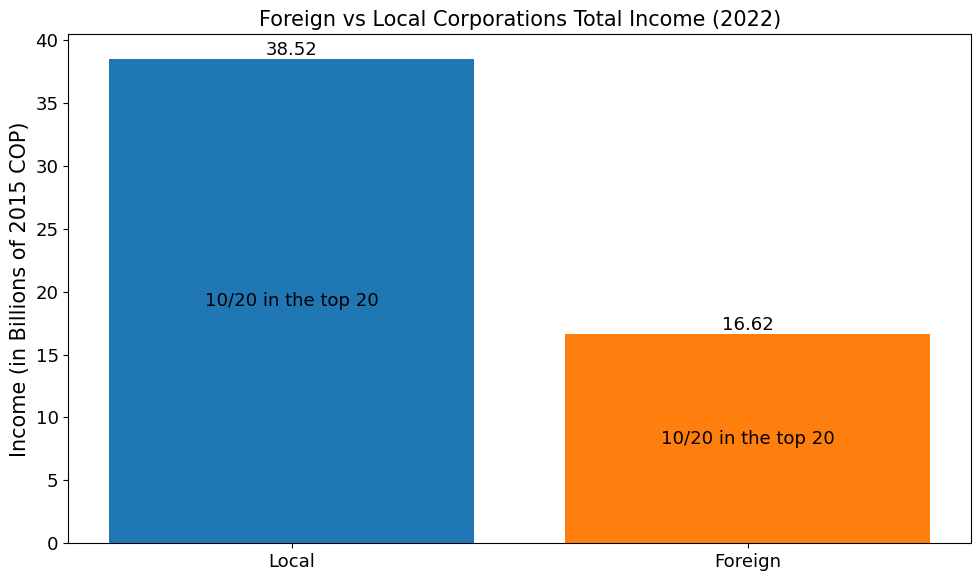

In [50]:
## assigning variables for totals
colombiano = locales['Income (deflated, 2015=100)'].sum()
eforaneas = foraneas['Income (deflated, 2015=100)'].sum()
## graph 9, top 20 corporation income totals, by Parent Company country of origin 
fig = plt.figure(figsize=(10,6))
axes = fig.subplots()
bar = axes.bar('Local',colombiano)
axes.bar_label(bar, fmt='%.2f')
axes.bar_label(bar, label_type='center',fmt='10/20 in the top 20')
bar2 = axes.bar('Foreign',eforaneas)
axes.bar_label(bar2, fmt='%.2f')
axes.bar_label(bar2, label_type='center',fmt='10/20 in the top 20')
plt.rcParams['font.size'] = 13
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.title('Foreign vs Local Corporations Total Income (2022)',fontsize=15)
axes.set_ylabel('Income (in Billions of 2015 COP)',fontsize=15)
plt.tight_layout()
plt.savefig('top202022foreignlocal.png')
plt.show()

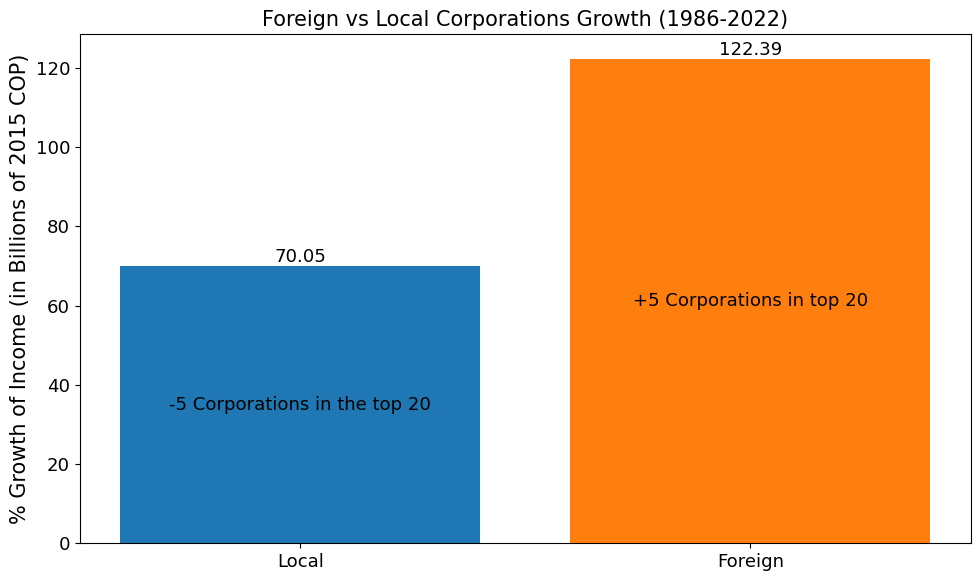

In [51]:
## Calculating growth rate between 1986-2022
localesgrowth = ((colombiano-colombiano4)/colombiano4)*100
ratagrowth = ((eforaneas-eforaneas4)/eforaneas4)*100
# graph 10, top 20 corporation totals growth rate, separated by Parent company country of origin
fig = plt.figure(figsize=(10,6))
axes = fig.subplots()
bar = axes.bar('Local',localesgrowth)
axes.bar_label(bar, fmt='%.2f')
axes.bar_label(bar, label_type='center',fmt='-5 Corporations in the top 20')
bar2 = axes.bar('Foreign',ratagrowth)
axes.bar_label(bar2, fmt='%.2f')
axes.bar_label(bar2, label_type='center',fmt='+5 Corporations in top 20')
plt.rcParams['font.size'] = 13
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.title('Foreign vs Local Corporations Growth (1986-2022)',fontsize=15)
axes.set_ylabel('% Growth of Income (in Billions of 2015 COP)',fontsize=15)
plt.tight_layout()
plt.savefig('top20foreignlocalgrowth.png')
plt.show()

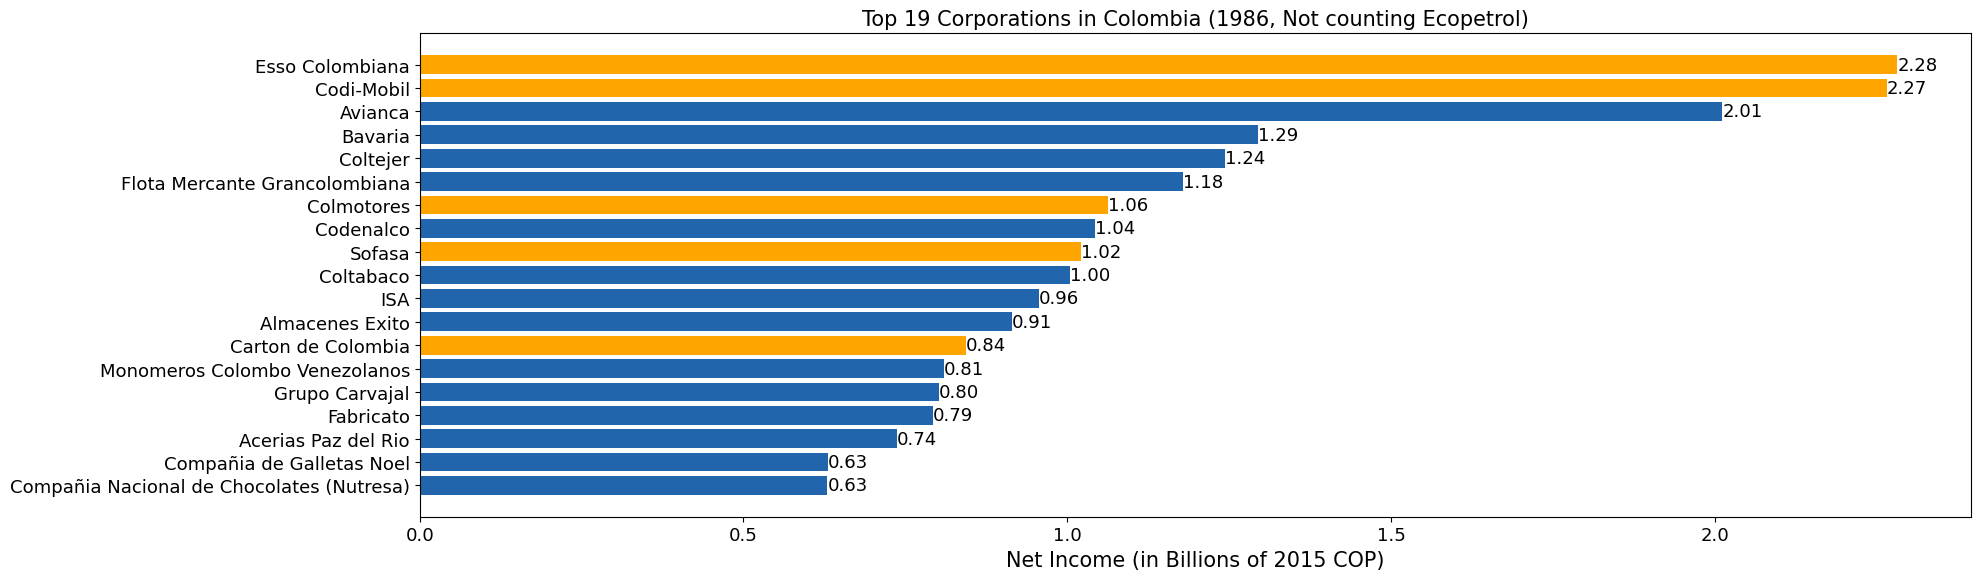

In [52]:
## graph 11, top 19 corporations by income in 1986, excluding Ecopetrol due to the huge size difference between itself and the rest of the top 20
fig = plt.figure(figsize=(20,6))
axes = fig.subplots()
colores = ['#FFA500','#FFA500','#2166ac','#2166ac','#2166ac','#2166ac','#FFA500','#2166ac','#FFA500','#2166ac','#2166ac','#2166ac','#FFA500','#2166ac','#2166ac','#2166ac','#2166ac','#2166ac','#2166ac']
bar = axes.barh(empresas4[1:],income1986[1:],color=colores)
axes.bar_label(bar, fmt='%.2f')
plt.rcParams['font.size'] = 13
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.title('Top 19 Corporations in Colombia (1986, Not counting Ecopetrol)',fontsize=15)
axes.set_xlabel('Net Income (in Billions of 2015 COP)',fontsize=15)
axes.invert_yaxis()
plt.tight_layout()
plt.savefig('top191986.png')
plt.show()

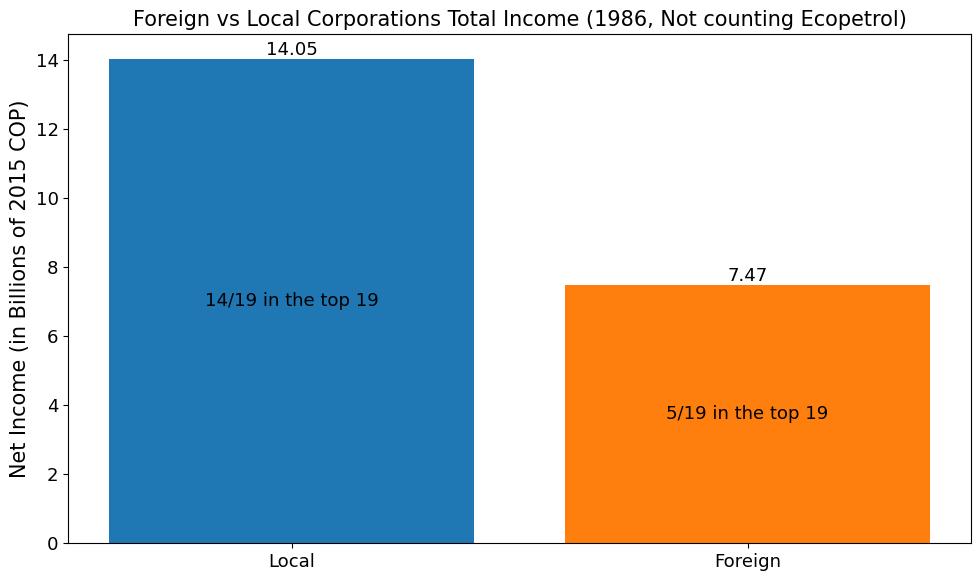

In [53]:
## creating new total variable excluding ecopetrol
colombiano1986 = locales1986[1:].sum()
## graph 12, top 19 corporation income totals in 1986, excluding Ecopetrol and separated by Parent company country of origin
fig = plt.figure(figsize=(10,6))
axes = fig.subplots()
bar = axes.bar('Local',colombiano1986)
axes.bar_label(bar, fmt='%.2f')
axes.bar_label(bar, label_type='center',fmt='14/19 in the top 19')
bar2 = axes.bar('Foreign',eforaneas4)
axes.bar_label(bar2, fmt='%.2f')
axes.bar_label(bar2, label_type='center',fmt='5/19 in the top 19')
plt.rcParams['font.size'] = 13
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.title('Foreign vs Local Corporations Total Income (1986, Not counting Ecopetrol)',fontsize=15)
axes.set_ylabel('Net Income (in Billions of 2015 COP)',fontsize=15)
plt.tight_layout()
plt.savefig('top191986foreignlocal.png')
plt.show()

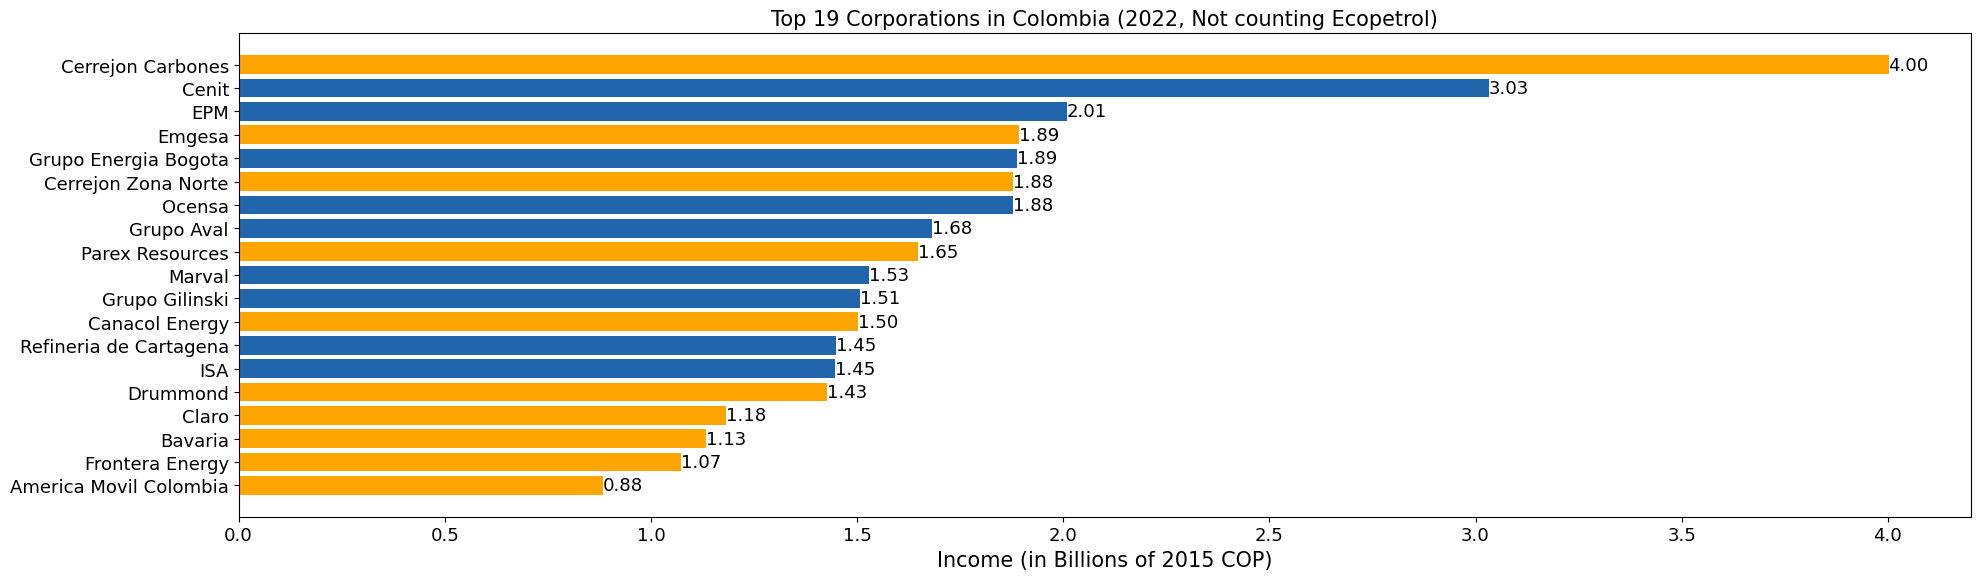

In [54]:
## graph 13, top 19 corporations by income in 2022, excluding Ecopetrol due to the huge size difference between itself and the rest of the top 20
fig = plt.figure(figsize=(20,6))
axes = fig.subplots()
colores = ['#FFA500','#2166ac','#2166ac','#FFA500','#2166ac','#FFA500','#2166ac','#2166ac','#FFA500','#2166ac','#2166ac','#FFA500','#2166ac','#2166ac','#FFA500','#FFA500','#FFA500','#FFA500','#FFA500']
bar = axes.barh(profitempresas[1:],income2022[1:],color=colores)
axes.bar_label(bar, fmt='%.2f')
plt.rcParams['font.size'] = 13
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.title('Top 19 Corporations in Colombia (2022, Not counting Ecopetrol)',fontsize=15)
axes.set_xlabel('Income (in Billions of 2015 COP)',fontsize=15)
axes.invert_yaxis()
plt.tight_layout()
plt.savefig('top192022.png')
plt.show()

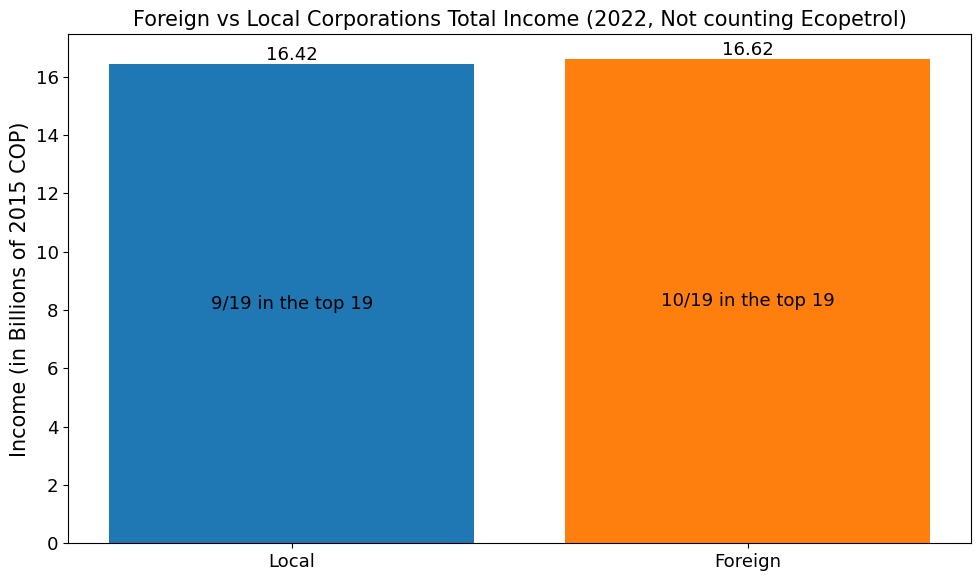

In [55]:
## assigning variable for new total excluding ecopetrol
colombiano2022 = locales['Income (deflated, 2015=100)'].iloc[1:].sum()
## graph 14, top 19 corporations by income total in 2022, excluding Ecopetrol, separated by Parent company country of origin
fig = plt.figure(figsize=(10,6))
axes = fig.subplots()
bar = axes.bar('Local',colombiano2022)
axes.bar_label(bar, fmt='%.2f')
axes.bar_label(bar, label_type='center',fmt='9/19 in the top 19')
bar2 = axes.bar('Foreign',eforaneas)
axes.bar_label(bar2, fmt='%.2f')
axes.bar_label(bar2, label_type='center',fmt='10/19 in the top 19')
plt.rcParams['font.size'] = 13
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.title('Foreign vs Local Corporations Total Income (2022, Not counting Ecopetrol)',fontsize=15)
axes.set_ylabel('Income (in Billions of 2015 COP)',fontsize=15)
plt.tight_layout()
plt.savefig('top192022foreignlocal.png')
plt.show()

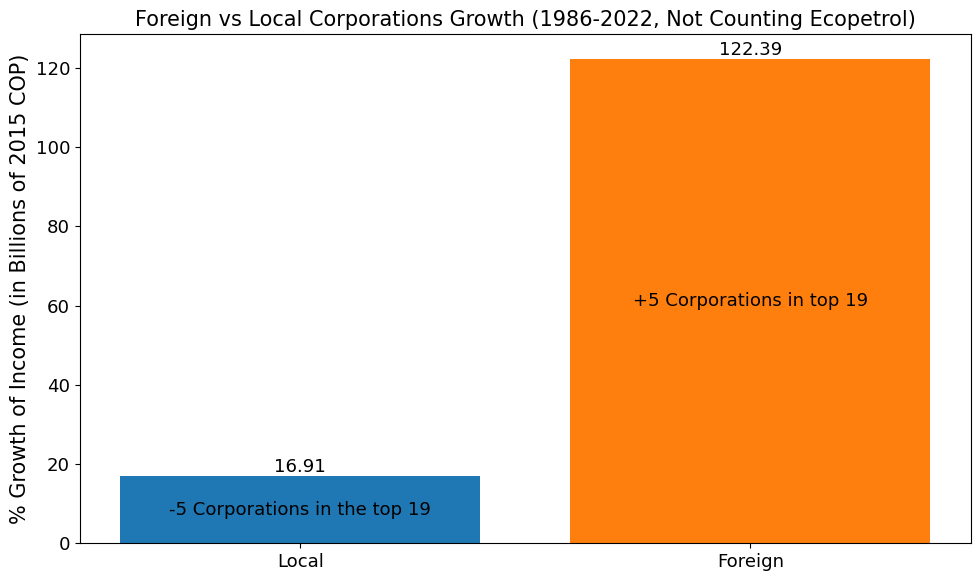

In [56]:
## calculating growth rate
localesgrowth2022 = ((colombiano2022-colombiano1986)/colombiano1986)*100
## ## graph 15, top 19 corporations income total growth rate, excluding Ecopetrol, separated by Parent company country of origin
fig = plt.figure(figsize=(10,6))
axes = fig.subplots()
bar = axes.bar('Local',localesgrowth2022)
axes.bar_label(bar, fmt='%.2f')
axes.bar_label(bar, label_type='center',fmt='-5 Corporations in the top 19')
bar2 = axes.bar('Foreign',ratagrowth)
axes.bar_label(bar2, fmt='%.2f')
axes.bar_label(bar2, label_type='center',fmt='+5 Corporations in top 19')
plt.rcParams['font.size'] = 13
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.title('Foreign vs Local Corporations Growth (1986-2022, Not Counting Ecopetrol)',fontsize=15)
axes.set_ylabel('% Growth of Income (in Billions of 2015 COP)',fontsize=15)
plt.tight_layout()
plt.savefig('top19foreignlocalgrowth.png')
plt.show()

In [57]:
## Foreign direct investment in Colombia total
ied2 = pd.read_excel(r"C:\Users\Lenovo\Earth Project\API_BX.KLT.DINV.CD.WD_DS2_en_excel_v2_29.xls",usecols='A,O:BO',skiprows=3,sheet_name='Data')
iedcolombia = pd.DataFrame(ied2.iloc[45].copy().reset_index())
iedcolombia.columns= ['Año','Colombia']
iedcolombia = iedcolombia.iloc[15:].reset_index(drop=True)
iedcolombia['Colombia'] = iedcolombia['Colombia'].astype(float)
## deflated, as well as growth rate calculation
iedcolombia['FDI (in Trillions 0f 2015 COP)'] = (((iedcolombia['Colombia']*dolarflatoravg2['TRM'].iloc[0:39]/deflator['Deflator'].iloc[0:39])*100)/1e12).astype(float)
ied = iedcolombia['FDI (in Trillions 0f 2015 COP)']
iedrate = (ied.copy().diff() / ied.copy().abs().shift())*100
iedrate.fillna(0,inplace=True)

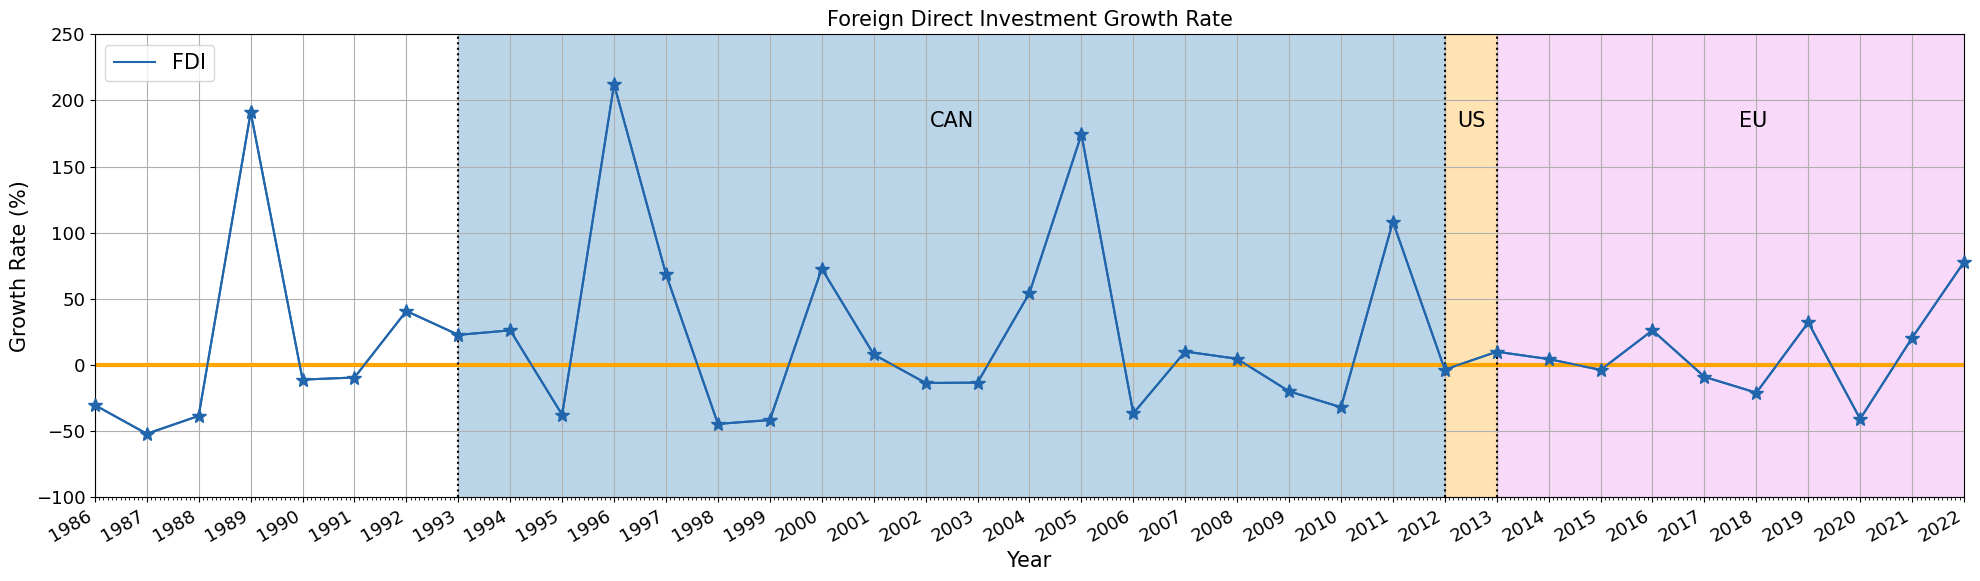

In [58]:
## graph 16, growth rate of FDI in Colombia
fig = plt.figure(figsize=(20,6))
axes = fig.subplots()
## dates
dates = iedcolombia['Año']
dates = pd.to_datetime(dates, format='%Y')
datesmin = dates.min()
datesmax = dates.max()
## title and labels
plt.title('Foreign Direct Investment Growth Rate',fontsize=15)
axes.set_ylabel('Growth Rate (%)',fontsize=15)
axes.set_xlabel('Year',fontsize=15)
## lines for each measure
axes.plot(dates,iedrate,color='#2166ac',label='FDI')
axes.plot(dates[2:],iedrate[2:],color='#2166ac',marker='*',markersize=10, clip_on=False,zorder=3)
# Set the major ticks to be at the beginning of each year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
## setting Months as minor ticks
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
# (Optional) You can disable the minor tick labels if you just want the ticks without labels
for label in plt.gca().xaxis.get_minorticklabels():
    label.set_visible(False)
# Improve the plot display
plt.gcf().autofmt_xdate()
## limits and grid
axes.set_ylim(top=250,bottom=-100)
axes.set_xlim(left=dt.date(1986,1,1),right=dt.date(2022, 1, 1))
## grid
axes.grid()
## label for axes2
axes2.set_ylabel('Exchange Rate Growth Rate (%)',fontsize=15,rotation=270,va='bottom')
axes2.invert_yaxis()
## horizontal line
axes.axhline(y=0,linewidth=3,zorder=2,color='#FFA500')
## Lines and Text for FTAs
axes.axvline(x=dt.date(1993, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2012, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2013, 1, 1),linestyle='dotted',color='k')
axes.text(dt.date(2002, 2, 1), 180, 'CAN',fontsize=15)
axes.text(dt.date(2012, 4, 1), 180, 'US',fontsize=15)
axes.text(dt.date(2017, 9, 1), 180, 'EU',fontsize=15)
## Boxes for amounts of FTAs active at the same time
xy = dt.datetime(1993,1,1), axes.get_ylim()[0]
w, h = dt.timedelta(days=6940), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy, w, h,alpha=0.3))
xy2 = dt.datetime(2012,1,1), axes.get_ylim()[0]
w2, h2 = dt.timedelta(days=365), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy2, w2, h2,alpha=0.3,color='orange'))
xy3 = dt.datetime(2013,1,1), axes.get_ylim()[0]
w3, h3 = dt.timedelta(days=3653), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy3, w3, h3,alpha=0.3,color='violet'))
## legend and setting it to upper left and upper right
axes.legend(loc=2,fontsize=15)
plt.tight_layout()
plt.savefig('iedcolombia.png')
plt.show()

In [59]:
## pulling data for GDP in constant PPP units, Price Purchase Parity is an unit used to compare different economies not with respect to the dollar
## it is calculated instead by using CPI as well as other measures of the internal economy and then it uses the measures for the US as its base
weodata = pd.read_excel(r"C:\Users\Lenovo\Earth Project\WEOApr2024all.xlsx",usecols='C,D,N:AZ')
weodata = weodata.loc[weodata['WEO Subject Code']=='PPPGDP']

In [60]:
## Colombia and 10 additional countries picked based on the closeness of their GDP to the colombian 1986 economy
weodata2= []
countriesweo = ['Poland','Taiwan Province of China','Austria','Peru','Egypt','Belgium','Philippines','Sweden','Pakistan','Thailand','Colombia']
n=0
for i in countriesweo:
    weodata2+=(weodata.loc[weodata['Country']==i].copy(),n)
    n+=1
weodata3 = weodata2[0::2]
weodata3 = pd.concat(weodata3)

In [61]:
## df fixing
weodata4 = weodata3.T.reset_index().copy()
weodata4.columns = weodata4.iloc[1]
weodata4 = weodata4.iloc[2:].reset_index(drop=True)
weodata4.rename(columns={'Country':'Año'},inplace=True)

In [62]:
## growth rate calculation
weogrowth = (weodata4.copy().diff() / weodata4.copy().abs().shift())*100
weogrowth['Año'] = weodata4['Año'].copy().astype(int)
weogrowth = weogrowth.iloc[2:].reset_index(drop=True)

In [63]:
## separating data for all countries from colombian data to calculate averages for the 10 and compare
coldata2= []
colcountries = ['Poland','Taiwan Province of China','Austria','Peru','Egypt','Belgium','Philippines','Sweden','Pakistan','Thailand']
n=0
for i in colcountries:
    coldata2+=[weogrowth[f'{i}'].copy(),n]
    n+=1
coldata3 = pd.DataFrame(coldata2[0::2])

In [64]:
## fixing df
coldata4 = coldata3.T.reset_index(drop=True).copy()
coldata5 = pd.DataFrame(coldata4.copy().T.mean())
coldata5.rename(columns={0:'10 Countries'},inplace=True)
coldata5.insert(0,'Año',weogrowth['Año'].copy())

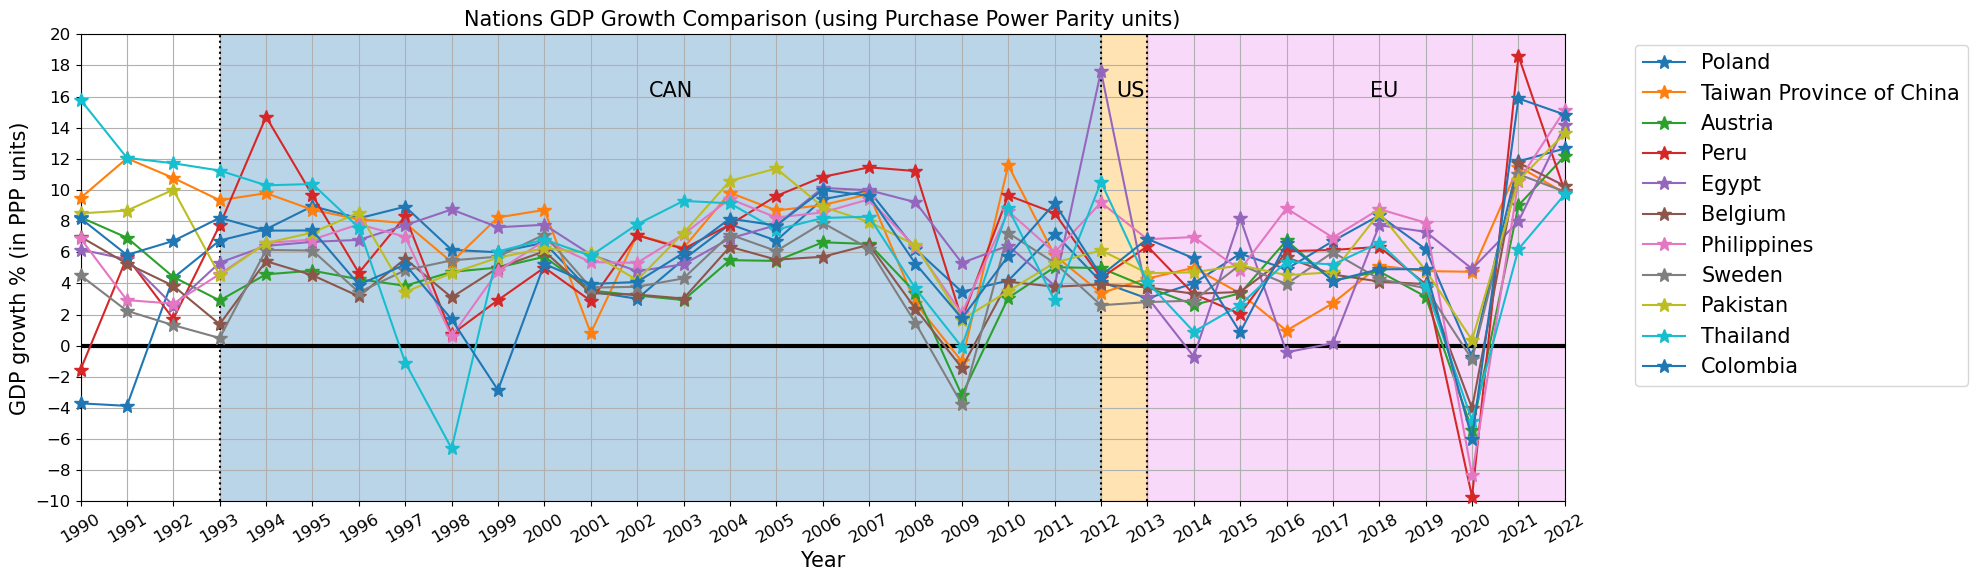

In [65]:
## assigning date variables
dates = weogrowth['Año']
datesmin = weogrowth['Año'].min()
datesmax = weogrowth['Año'].max()
## graph 17, graphing all nations, this graph is mostly symbolical since it's too messy
fig = plt.figure(figsize=(20,6))
axes = fig.subplots()
plt.title('Nations GDP Growth Comparison (using Purchase Power Parity units)',fontsize=15)
axes.set_ylabel('GDP growth % (in PPP units)',fontsize=15)
axes.set_xlabel('Year',fontsize=15)
# for loop
for i in countriesweo:
    axes.plot(weogrowth['Año'].iloc[4:],weogrowth[i].iloc[4:],label=i,marker='*',markersize=10, clip_on=False,zorder=3)
## limits and grid
axes.set_xlim(left=1990,right=datesmax)
axes.set_ylim(top=20,bottom=-10)
## grid
axes.grid()
## ticks fix
axes.tick_params(axis='both', which='major', labelsize=12)
axes.axhline(y=0,linewidth=3,zorder=2,color='#000000')
## Lines and Text for FTAs
axes.axvline(x=1993,linestyle='dotted',color='k')
axes.axvline(x=2012,linestyle='dotted',color='k')
axes.axvline(x=2013,linestyle='dotted',color='k')
axes.text(2002.25, 16, 'CAN',fontsize=15)
axes.text(2012.33, 16, 'US',fontsize=15)
axes.text(2017.8, 16, 'EU',fontsize=15)
## Boxes for amounts of FTAs active at the same time
xy = 1993, axes.get_ylim()[0]
w, h = 19, axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy, w, h,alpha=0.3))
xy2 = 2012, axes.get_ylim()[0]
w2, h2 = 1, axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy2, w2, h2,alpha=0.3,color='orange'))
xy3 = 2013, axes.get_ylim()[0]
w3, h3 = 10, axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy3, w3, h3,alpha=0.3,color='violet'))
## ticks
plt.xticks(np.arange(1990, 2023, step=1),rotation=30)
plt.yticks(np.arange(-10, 21, step=2))
## legend and setting it to upper left and upper right
axes.legend(loc='best',fontsize=15,bbox_to_anchor=(1.04, 1))
plt.tight_layout()
plt.savefig('weogrowth.png')
plt.show()

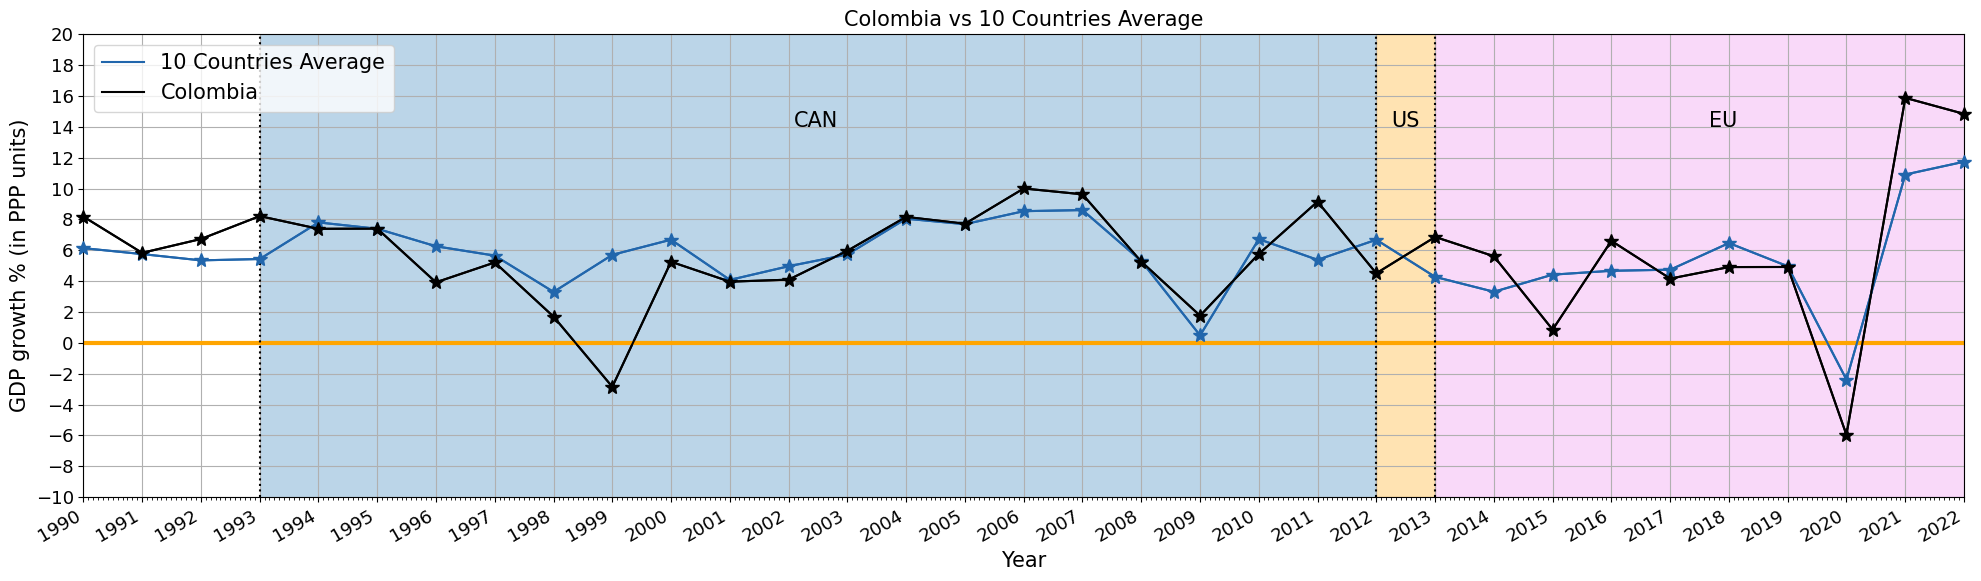

In [66]:
## graph 18, Colombia and the 10 countries average
fig = plt.figure(figsize=(20,6))
axes = fig.subplots()
## dates
dates = coldata5['Año']
dates = pd.to_datetime(dates, format='%Y')
datesmin = dates.min()
datesmax = dates.max()
coldatarate = coldata5['10 Countries']
colombia = weogrowth['Colombia']
## title and labels
plt.title('Colombia vs 10 Countries Average',fontsize=15)
axes.set_ylabel('GDP growth % (in PPP units)',fontsize=15)
axes.set_xlabel('Year',fontsize=15)
## lines for each measure
axes.plot(dates,coldatarate,color='#2166ac',label='10 Countries Average')
axes.plot(dates[4:],coldatarate[4:],color='#2166ac',marker='*',markersize=10, clip_on=False,zorder=3)
axes.plot(dates,colombia,color='k',label='Colombia')
axes.plot(dates[4:],colombia[4:],color='k',marker='*',markersize=10, clip_on=False,zorder=3)
# Set the major ticks to be at the beginning of each year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
## setting Months as minor ticks
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
# (Optional) You can disable the minor tick labels if you just want the ticks without labels
for label in plt.gca().xaxis.get_minorticklabels():
    label.set_visible(False)
# Improve the plot display
plt.gcf().autofmt_xdate()
## limits and grid
axes.set_ylim(top=20,bottom=-10)
axes.set_xlim(left=dt.date(1990,1,1),right=dt.date(2022, 1, 1))
## grid
axes.grid()
## label for axes2
axes2.set_ylabel('Exchange Rate Growth Rate (%)',fontsize=15,rotation=270,va='bottom')
axes2.invert_yaxis()
## horizontal line
axes.axhline(y=0,linewidth=3,zorder=2,color='#FFA500')
## Lines and Text for FTAs
axes.axvline(x=dt.date(1993, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2012, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2013, 1, 1),linestyle='dotted',color='k')
axes.text(dt.date(2002, 2, 1), 14, 'CAN',fontsize=15)
axes.text(dt.date(2012, 4, 1), 14, 'US',fontsize=15)
axes.text(dt.date(2017, 9, 1), 14, 'EU',fontsize=15)
## Boxes for amounts of FTAs active at the same time
xy = dt.datetime(1993,1,1), axes.get_ylim()[0]
w, h = dt.timedelta(days=6940), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy, w, h,alpha=0.3))
xy2 = dt.datetime(2012,1,1), axes.get_ylim()[0]
w2, h2 = dt.timedelta(days=365), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy2, w2, h2,alpha=0.3,color='orange'))
xy3 = dt.datetime(2013,1,1), axes.get_ylim()[0]
w3, h3 = dt.timedelta(days=3653), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy3, w3, h3,alpha=0.3,color='violet'))
## yticks
plt.yticks(np.arange(-10, 21, step=2))
## legend and setting it to upper left and upper right
axes.legend(loc=2,fontsize=15)
plt.tight_layout()
plt.savefig('coldata.png')
plt.show()

In [67]:
## Unemployment data for nations from IMF
unemployment = pd.read_excel(r"C:\Users\Lenovo\Earth Project\WEOApr2024all.xlsx",usecols='C,D,N:AZ')
unemployment = unemployment.loc[unemployment['WEO Subject Code']=='LUR']

In [68]:
## separating colombian data
unemployment2 = unemployment.loc[unemployment['Country']=='Colombia'].copy()
unemployment2 = unemployment2.copy().T.reset_index()
unemployment2.columns = ['Año','Colombia']
unemployment3 = unemployment2.iloc[2:]

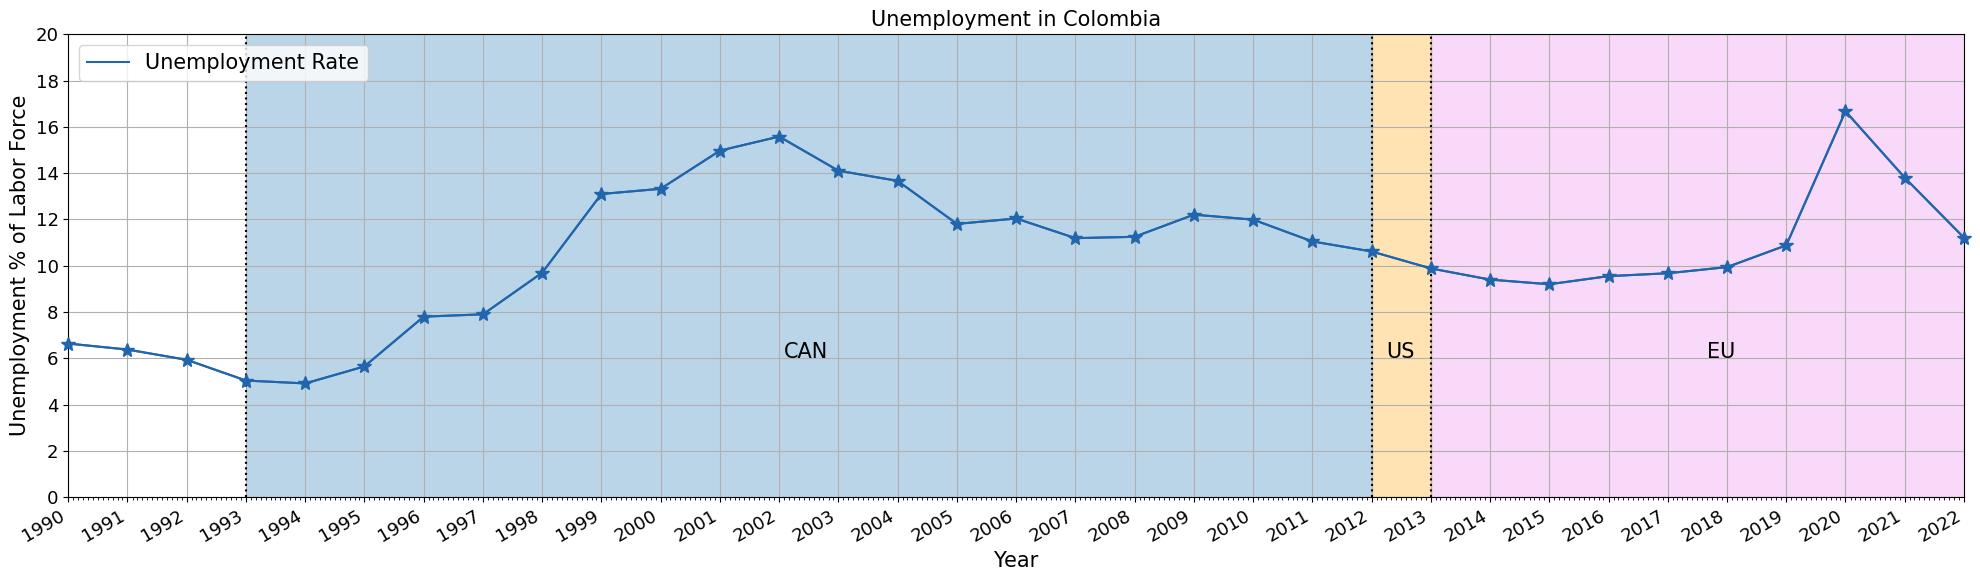

In [69]:
## graph 19, unemployment in Colombia
fig = plt.figure(figsize=(20,6))
axes = fig.subplots()
## dates
colrate = unemployment3['Colombia']
dates = unemployment3['Año']
dates = pd.to_datetime(dates, format='%Y')
datesmin = dates.min()
datesmax = dates.max()
## title and labels
plt.title('Unemployment in Colombia',fontsize=15)
axes.set_ylabel('Unemployment % of Labor Force',fontsize=15)
axes.set_xlabel('Year',fontsize=15)
## lines for each measure
axes.plot(dates,colrate,color='#2166ac',label='Unemployment Rate')
axes.plot(dates[6:],colrate[6:],color='#2166ac',marker='*',markersize=10, clip_on=False,zorder=3)
# Set the major ticks to be at the beginning of each year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
## setting Months as minor ticks
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
# (Optional) You can disable the minor tick labels if you just want the ticks without labels
for label in plt.gca().xaxis.get_minorticklabels():
    label.set_visible(False)
# Improve the plot display
plt.gcf().autofmt_xdate()
## limits and grid
axes.set_ylim(top=20,bottom=0)
axes.set_xlim(left=dt.date(1990,1,1),right=dt.date(2022, 1, 1))
## grid
axes.grid()
## Lines and Text for FTAs
axes.axvline(x=dt.date(1993, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2012, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2013, 1, 1),linestyle='dotted',color='k')
axes.text(dt.date(2002, 2, 1), 6, 'CAN',fontsize=15)
axes.text(dt.date(2012, 4, 1), 6, 'US',fontsize=15)
axes.text(dt.date(2017, 9, 1), 6, 'EU',fontsize=15)
## Boxes for amounts of FTAs active at the same time
xy = dt.datetime(1993,1,1), axes.get_ylim()[0]
w, h = dt.timedelta(days=6940), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy, w, h,alpha=0.3))
xy2 = dt.datetime(2012,1,1), axes.get_ylim()[0]
w2, h2 = dt.timedelta(days=365), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy2, w2, h2,alpha=0.3,color='orange'))
xy3 = dt.datetime(2013,1,1), axes.get_ylim()[0]
w3, h3 = dt.timedelta(days=3653), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy3, w3, h3,alpha=0.3,color='violet'))
# yticks
plt.yticks(np.arange(0, 21, step=2))
## legend and setting it to upper left and upper right
axes.legend(loc=2,fontsize=15)
plt.tight_layout()
plt.savefig('unemployment.png')
plt.show()

In [70]:
## pulling all unemployment data separately
unemployment1 = pd.read_excel(r"C:\Users\Lenovo\Earth Project\WEOApr2024all.xlsx",usecols='C,D,T:AZ')
unemployment1 = unemployment.loc[unemployment['WEO Subject Code']=='LUR']

In [71]:
## data for the unemployment of the 10 countries
urate2= []
uratecountries = ['Poland','Taiwan Province of China','Austria','Peru','Egypt','Belgium','Philippines','Sweden','Pakistan','Thailand']
n=0
for i in uratecountries:
    urate2+=[unemployment1.loc[unemployment1['Country']==i].copy(),n]
    n+=1
urate3 = urate2[0::2]
unemployment12 = pd.concat(urate3).copy().T.reset_index()
unemployment12.columns = unemployment12.iloc[1]
unemployment22 = unemployment12.iloc[8:].copy().reset_index(drop=True)
unemployment22.rename(columns={'Country':'Año'},inplace=True)

In [72]:
## average for the 10 countries
unemployment23 = unemployment22.copy()
unemployment23.drop(columns=['Año'],inplace=True)
unemployment24 = unemployment23.copy().T.mean()

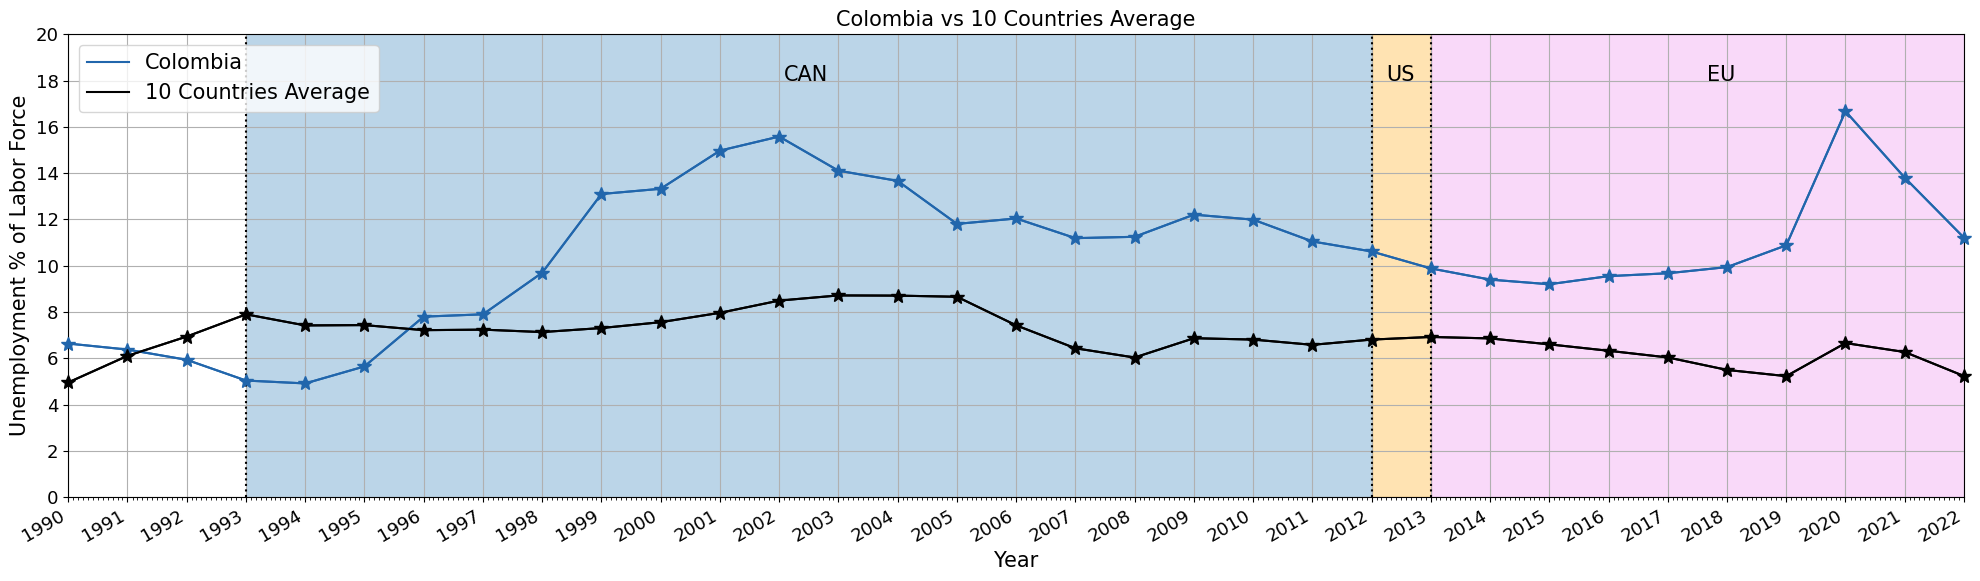

In [73]:
## graph 20, Unemployment in colombia and the average of the 10 countries
fig = plt.figure(figsize=(20,6))
axes = fig.subplots()
## dates
colrate = unemployment3['Colombia']
worldrate = unemployment24
dates2 = unemployment22['Año']
dates2 =  pd.to_datetime(dates2, format='%Y')
dates = unemployment3['Año']
dates = pd.to_datetime(dates, format='%Y')
datesmin = dates.min()
datesmax = dates.max()
## title and labels
plt.title('Colombia vs 10 Countries Average',fontsize=15)
axes.set_ylabel('Unemployment % of Labor Force',fontsize=15)
axes.set_xlabel('Year',fontsize=15)
## lines for each measure
axes.plot(dates,colrate,color='#2166ac',label='Colombia')
axes.plot(dates[6:],colrate[6:],color='#2166ac',marker='*',markersize=10, clip_on=False,zorder=3)
axes.plot(dates2,worldrate,color='k',label='10 Countries Average')
axes.plot(dates2,worldrate,color='k',marker='*',markersize=10, clip_on=False,zorder=3)
# Set the major ticks to be at the beginning of each year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
## setting Months as minor ticks
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
# (Optional) You can disable the minor tick labels if you just want the ticks without labels
for label in plt.gca().xaxis.get_minorticklabels():
    label.set_visible(False)
# Improve the plot display
plt.gcf().autofmt_xdate()
## limits and grid
axes.set_ylim(top=20,bottom=0)
axes.set_xlim(left=dt.date(1990,1,1),right=dt.date(2022, 1, 1))
## grid
axes.grid()
## Lines and Text for FTAs
axes.axvline(x=dt.date(1993, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2012, 1, 1),linestyle='dotted',color='k')
axes.axvline(x=dt.date(2013, 1, 1),linestyle='dotted',color='k')
axes.text(dt.date(2002, 2, 1), 18, 'CAN',fontsize=15)
axes.text(dt.date(2012, 4, 1), 18, 'US',fontsize=15)
axes.text(dt.date(2017, 9, 1), 18, 'EU',fontsize=15)
## Boxes for amounts of FTAs active at the same time
xy = dt.datetime(1993,1,1), axes.get_ylim()[0]
w, h = dt.timedelta(days=6940), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy, w, h,alpha=0.3))
xy2 = dt.datetime(2012,1,1), axes.get_ylim()[0]
w2, h2 = dt.timedelta(days=365), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy2, w2, h2,alpha=0.3,color='orange'))
xy3 = dt.datetime(2013,1,1), axes.get_ylim()[0]
w3, h3 = dt.timedelta(days=3653), axes.get_ylim()[1] - axes.get_ylim()[0]
axes.add_patch(Rectangle(xy3, w3, h3,alpha=0.3,color='violet'))
# yticks
plt.yticks(np.arange(0, 21, step=2))
## legend and setting it to upper left and upper right
axes.legend(loc=2,fontsize=15)
plt.tight_layout()
plt.savefig('unemploymentworld.png')
plt.show()